# Fuzzy Support Vector Machine (FSVM) Implementation

## Cel laboratorium
Implementacja Fuzzy SVM w oparciu o artykuł "Fuzzy Support Vector Machines" oraz porównanie wyników z klasycznym SVM.

### Teoria Fuzzy SVM
Fuzzy SVM rozszerza klasyczny SVM poprzez przypisanie każdemu punktowi treningowemu wartości przynależności (membership value) **s_i ∈ (0, 1]**. Ta wartość określa "ważność" punktu w procesie uczenia:
- Punkty z wysoką przynależnością (bliskie 1) mają większy wpływ na hyperplane
- Punkty z niską przynależnością (bliskie 0) - prawdopodobne outliers - mają mniejszy wpływ

### Modyfikacja funkcji celu
Klasyczny SVM:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i$$

Fuzzy SVM:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n s_i\xi_i$$

gdzie **s_i** to fuzzy membership value.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Implementacja Fuzzy SVM

### Metody obliczania Fuzzy Membership

Zaimplementujemy kilka metod obliczania wartości przynależności:

1. **Distance-based membership**: Bazuje na odległości punktu od centroidu klasy
   - Punkty bliższe centroidowi mają wyższą przynależność
   
2. **Radius-based membership**: Wykorzystuje promień dla każdej klasy
   - Punkty w promieniu r od centroidu mają pełną przynależność
   
3. **KNN-based membership**: Bazuje na lokalnej gęstości punktów
   - Wykorzystuje odległość do k-tego najbliższego sąsiada

In [15]:
class SVM: 
    """
    Własna implementacja SVM z optymalizacją dualną.
    """
    def __init__(self, kernel='linear', learning_rate=0.5, C=1.0, poly_degree=3, gamma=0.5):
        self.lr = learning_rate
        self.kernel = kernel
        self.degree = poly_degree
        self.gamma = gamma
        self.C = C
        self.lambdas = None
        self.X = None
        self.y = None
        self.b = None
        self.support_vectors = None

    def kernel_function(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        elif self.kernel == 'poly':
            return ((X1 @ X2.T) + 1) ** self.degree
        elif self.kernel == 'rbf':
            X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
            dist = X1_sq - 2 * X1 @ X2.T + X2_sq
            return np.exp(-self.gamma * dist)
    
    def dual_svm(self, lambdas, X, y):
        K = self.kernel_function(X, X)
        L = np.outer(lambdas, lambdas)
        Y = np.outer(y, y)
        return -np.sum(lambdas) + 0.5 * np.sum(L * Y * K)
        
    def fit(self, X, y):
        n_samples = X.shape[0]
        self.X = X
        self.y = y

        # Ograniczenia
        bounds = [(0, self.C) for _ in range(n_samples)]
        constraints = {'type': 'eq', 'fun': lambda l: np.dot(l, y)}

        init_lambdas = np.random.rand(n_samples)

        result = minimize(
            fun=self.dual_svm,
            x0=init_lambdas,
            args=(X, y),
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            options={'disp': False, 'maxiter': 1000}
        )
        self.lambdas = result.x

        tol = 1e-5
        self.support_vectors = self.lambdas > tol

        # Wybieramy punkty z przedziału (0, C) czyli punkty nośne na granicy marginesu
        margin_sv = (self.lambdas > tol) & (self.lambdas < self.C - tol)
        margin_points = margin_sv if np.any(margin_sv) else self.support_vectors

        sv_y = y[margin_points] 
        K = self.kernel_function(X[margin_points], X[self.support_vectors])
        lambdas_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        self.b = np.mean(sv_y - np.dot(K, lambdas_y))

    def prepare_predict(self, X):
        K = self.kernel_function(X, self.X[self.support_vectors])
        l_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        return np.dot(K, l_y) + self.b

    def predict(self, X):
        return np.sign(self.prepare_predict(X))
    
    @property
    def n_support_(self):
        """Zwraca liczbę support vectors dla zgodności z API."""
        if self.support_vectors is None:
            return 0
        return [np.sum(self.support_vectors)]
    
    @property
    def support_vectors_(self):
        """Zwraca support vectors dla zgodności z API."""
        if self.support_vectors is None or self.X is None:
            return None
        return self.X[self.support_vectors]

### Własna implementacja SVM

Wykorzystujemy własną implementację SVM bazującą na optymalizacji dualnej.

### Kluczowa różnica: Fuzzy SVM vs Klasyczny SVM

**Klasyczny SVM** - ograniczenia na lambdy:
```
0 ≤ λ_i ≤ C    dla wszystkich i
```

**Fuzzy SVM** - ograniczenia z fuzzy membership:
```
0 ≤ λ_i ≤ C × s_i    dla wszystkich i
```

gdzie **s_i ∈ (0, 1]** to fuzzy membership value punktu i.

**Efekt**: 
- Punkty z wysokim **s_i** (bliskie 1) mogą mieć lambdy do **C** - normalny wpływ
- Punkty z niskim **s_i** (outliery) mają ograniczone lambdy do **C × s_i** - zmniejszony wpływ
- To odpowiada modyfikacji funkcji celu: `min 1/2||w||² + C × Σ(s_i × ξ_i)`

In [ ]:
class FuzzySVM:
    """
    Fuzzy Support Vector Machine implementation - rozszerzenie własnego SVM.
    
    Fuzzy SVM przypisuje każdemu punktowi treningowemu wartość przynależności (membership value),
    która określa jego wpływ na proces uczenia poprzez modyfikację ograniczeń na lambdy.
    
    Zamiast: 0 <= lambda_i <= C
    Mamy:    0 <= lambda_i <= C * s_i
    
    gdzie s_i to fuzzy membership value dla punktu i.
    """
    
    def __init__(self, kernel='rbf', C=1.0, gamma=0.5, poly_degree=3,
                 membership_type='distance', k_neighbors=5):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.poly_degree = poly_degree
        self.membership_type = membership_type
        self.k_neighbors = k_neighbors
        self.svm = None
        self.memberships = None
        
    def compute_distance_membership(self, X, y):
        """
        Membership na podstawie odległości od centroidu klasy.
        """
        memberships = np.ones(len(X))
        classes = np.unique(y)
        
        for c in classes:
            class_mask = (y == c)
            X_class = X[class_mask]
            
            centroid = np.mean(X_class, axis=0)
            
            distances = np.linalg.norm(X_class - centroid, axis=1)
            
            max_dist = np.max(distances) if np.max(distances) > 0 else 1.0
            memberships[class_mask] = 1.0 - (distances / max_dist) * 0.9 + 0.1
            
        return memberships
    
    
    def compute_sequential_membership(self, X, y, decay_factor=0.9):
        """
        membership na podstawie kolejności danych (sekwencyjnej).
        """
        n_samples = len(X)
        memberships = np.zeros(n_samples)

        for i in range(n_samples):
            position_from_end = n_samples - 1 - i
            memberships[i] = decay_factor ** position_from_end
        
        memberships = memberships * 0.9 + 0.1
        
        return memberships
    
    def compute_class_weight_membership(self, X, y, positive_weight=1.0, negative_weight=0.1):
        """
        Oblicza fuzzy membership na podstawie różnej ważności klas.
        """
        
        memberships = np.where(y == 1, positive_weight, negative_weight)
        return memberships
    
    def compute_combined_membership(self, X, y, methods=['distance', 'sequential'], weights=None):
        """
        Oblicza fuzzy membership jako kombinację różnych metod.
        
        Pozwala na łączenie różnych podejść, np.:
        - Odległość od centroidu + ważność sekwencyjna
        - Lokalna gęstość + różna ważność klas
        
        Parametry:
        -----------
        X : array-like
            Dane treningowe
        y : array-like
            Etykiety
        methods : list of str
            Lista metod do połączenia: 'distance', 'radius', 'knn', 'sequential', 'class_weight'
        weights : list of float, optional
            Wagi dla poszczególnych metod. Jeśli None, wszystkie mają równe wagi.
        
        Returns:
        --------
        memberships : ndarray
            Średnia ważona membership values z różnych metod
        """
        if weights is None:
            weights = [1.0 / len(methods)] * len(methods)
        else:
            # Normalizuj wagi
            weights = np.array(weights) / np.sum(weights)
        
        combined_memberships = np.zeros(len(X))
        
        for method, weight in zip(methods, weights):
            if method == 'distance':
                m = self.compute_distance_membership(X, y)
            elif method == 'sequential':
                m = self.compute_sequential_membership(X, y)
            elif method == 'class_weight':
                m = self.compute_class_weight_membership(X, y)
            else:
                raise ValueError(f"Unknown method: {method}")
            
            combined_memberships += weight * m
        
        return combined_memberships
    
    def fit(self, X, y):
        """
        Trenuje Fuzzy SVM z własną implementacją.
        
        Parametry:
        ----------
        X : array-like, shape (n_samples, n_features)
            Dane treningowe
        y : array-like, shape (n_samples,)
            Etykiety klas (muszą być -1 i 1)
        """
        # Konwertuj etykiety na -1 i 1 jeśli są w formacie 0 i 1
        y_converted = np.where(y == 0, -1, y)
        
        # Oblicz fuzzy membership values
        if self.membership_type == 'distance':
            self.memberships = self.compute_distance_membership(X, y_converted)
        elif self.membership_type == 'radius':
            self.memberships = self.compute_radius_membership(X, y_converted)
        elif self.membership_type == 'knn':
            self.memberships = self.compute_knn_membership(X, y_converted)
        elif self.membership_type == 'sequential':
            self.memberships = self.compute_sequential_membership(X, y_converted)
        elif self.membership_type == 'class_weight':
            self.memberships = self.compute_class_weight_membership(X, y_converted)
        elif self.membership_type == 'combined':
            # Domyślna kombinacja: distance + sequential
            self.memberships = self.compute_combined_membership(X, y_converted)
        else:
            raise ValueError(f"Unknown membership type: {self.membership_type}")
        
        # Utworz Fuzzy SVM - modyfikujemy ograniczenia na lambdy
        self.svm = FuzzySVMCore(
            kernel=self.kernel,
            C=self.C,
            gamma=self.gamma,
            poly_degree=self.poly_degree,
            memberships=self.memberships  # Przekazujemy membership values
        )
        
        self.svm.fit(X, y_converted)
        
        return self
    
    def predict(self, X):
        """Predykcja klas dla nowych danych."""
        predictions = self.svm.predict(X)
        # Konwertuj z powrotem na 0 i 1 jeśli potrzeba
        return np.where(predictions == -1, 0, 1)
    
    def score(self, X, y):
        """Oblicza accuracy na danych testowych."""
        predictions = self.predict(X)
        return accuracy_score(y, predictions)
    
    def get_memberships(self):
        """Zwraca wartości fuzzy membership dla danych treningowych."""
        return self.memberships


class FuzzySVMCore(SVM):
    """
    Rozszerzenie bazowego SVM o fuzzy membership.
    Modyfikuje ograniczenia na lambdy: 0 <= lambda_i <= C * s_i
    """
    
    def __init__(self, kernel='rbf', C=1.0, gamma=0.5, poly_degree=3, memberships=None):
        super().__init__(kernel=kernel, C=C, gamma=gamma, poly_degree=poly_degree)
        self.memberships = memberships
        
    def fit(self, X, y):
        """
        Trenuje Fuzzy SVM z zmodyfikowanymi ograniczeniami.
        """
        n_samples = X.shape[0]
        self.X = X
        self.y = y

        # KLUCZOWA MODYFIKACJA: Ograniczenia z fuzzy membership
        # Zamiast bounds = [(0, C) for _ in range(n_samples)]
        # Mamy:   bounds = [(0, C * s_i) for i in range(n_samples)]
        if self.memberships is not None:
            bounds = [(0, self.C * s_i) for s_i in self.memberships]
        else:
            bounds = [(0, self.C) for _ in range(n_samples)]
            
        constraints = {'type': 'eq', 'fun': lambda l: np.dot(l, y)}

        init_lambdas = np.random.rand(n_samples)

        result = minimize(
            fun=self.dual_svm,
            x0=init_lambdas,
            args=(X, y),
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            options={'disp': False, 'maxiter': 1000}
        )
        self.lambdas = result.x

        tol = 1e-5
        self.support_vectors = self.lambdas > tol

        # Oblicz bias
        if self.memberships is not None:
            # Dla Fuzzy SVM: punkty na marginesie mają 0 < lambda_i < C * s_i
            margin_sv = (self.lambdas > tol) & (self.lambdas < np.array([self.C * s_i for s_i in self.memberships]) - tol)
        else:
            margin_sv = (self.lambdas > tol) & (self.lambdas < self.C - tol)
            
        margin_points = margin_sv if np.any(margin_sv) else self.support_vectors

        sv_y = y[margin_points] 
        K = self.kernel_function(X[margin_points], X[self.support_vectors])
        lambdas_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        self.b = np.mean(sv_y - np.dot(K, lambdas_y))

## 2. Generowanie danych z outlierami

Utworzymy zbiór danych z celowo dodanymi outlierami, aby pokazać przewagę Fuzzy SVM nad klasycznym SVM.

In [17]:
def create_dataset_with_outliers(n_samples=300, outlier_ratio=0.1, noise=0.1, random_state=42):
    """
    Tworzy zbiór danych z outlierami.
    
    Parametry:
    ----------
    n_samples : int
        Liczba próbek
    outlier_ratio : float
        Procent outlierów do dodania
    noise : float
        Poziom szumu w danych
    random_state : int
        Ziarno losowości
    """
    np.random.seed(random_state)
    
    # Generuj podstawowy zbiór danych (moon shapes)
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    
    # Dodaj outliery
    n_outliers = int(n_samples * outlier_ratio)
    outlier_indices = np.random.choice(n_samples, n_outliers, replace=False)
    
    # Outliery to punkty z dużym przesunięciem
    for idx in outlier_indices:
        X[idx] += np.random.randn(2) * 2.0
    
    return X, y, outlier_indices

# Tworzenie różnych zestawów danych
print("Tworzenie zestawów danych...")

# Dataset 1: Moon shapes z outlierami
X_moon, y_moon, outliers_moon = create_dataset_with_outliers(
    n_samples=300, outlier_ratio=0.15, noise=0.15, random_state=42
)

# Dataset 2: Circles z outlierami
X_circle, y_circle = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
n_outliers = int(300 * 0.15)
outlier_indices_circle = np.random.choice(300, n_outliers, replace=False)
for idx in outlier_indices_circle:
    X_circle[idx] += np.random.randn(2) * 1.5
outliers_circle = outlier_indices_circle

# Dataset 3: Klasyfikacja liniowa z outlierami
X_linear, y_linear = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, random_state=42, flip_y=0.1
)
n_outliers = int(300 * 0.15)
outlier_indices_linear = np.random.choice(300, n_outliers, replace=False)
for idx in outlier_indices_linear:
    X_linear[idx] += np.random.randn(2) * 3.0
outliers_linear = outlier_indices_linear

print(f"Utworzono 3 zestawy danych, każdy z ~15% outlierów")
print(f"Dataset Moon: {X_moon.shape}, outliers: {len(outliers_moon)}")
print(f"Dataset Circle: {X_circle.shape}, outliers: {len(outliers_circle)}")
print(f"Dataset Linear: {X_linear.shape}, outliers: {len(outliers_linear)}")

Tworzenie zestawów danych...
Utworzono 3 zestawy danych, każdy z ~15% outlierów
Dataset Moon: (300, 2), outliers: 45
Dataset Circle: (300, 2), outliers: 45
Dataset Linear: (300, 2), outliers: 45


## 3. Wizualizacja danych i fuzzy membership

Zobaczmy jak wyglądają dane oraz wartości przynależności dla różnych metod.

### Nowe metody Fuzzy Membership

Dodatkowe metody obliczania membership values:

**1. Sequential Membership** - dane sekwencyjne (nowsze ważniejsze):
$$s_i = \alpha^{(n-i)} \times 0.9 + 0.1$$
gdzie $\alpha$ to decay factor (np. 0.9), $n$ to liczba próbek, $i$ to indeks próbki

**2. Class Weight Membership** - różna ważność klas:
$$s_i = \begin{cases} 
1.0 & \text{jeśli } y_i = +1 \\
0.1 & \text{jeśli } y_i = -1
\end{cases}$$

**3. Combined Membership** - kombinacja metod:
$$s_i = \sum_{j=1}^{m} w_j \times s_i^{(j)}$$
gdzie $w_j$ to wagi, $s_i^{(j)}$ to membership z j-tej metody

In [ ]:
# Demonstracja nowych metod membership
def visualize_new_memberships(X, y, title="New Membership Methods"):
    """Wizualizuje nowe metody fuzzy membership."""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Konwertuj etykiety
    y_converted = np.where(y == 0, -1, y)
    
    # 1. Sequential Membership
    ax = axes[0, 0]
    fsvm_seq = FuzzySVM(membership_type='sequential')
    memberships_seq = fsvm_seq.compute_sequential_membership(X, y_converted, decay_factor=0.9)
    
    scatter = ax.scatter(X[:, 0], X[:, 1], c=memberships_seq, 
                       cmap='viridis', s=50, alpha=0.8, 
                       edgecolors='k', linewidth=0.5, vmin=0, vmax=1)
    
    # Dodaj strzałkę pokazującą kierunek czasu
    ax.annotate('Starsze dane', xy=(X[0, 0], X[0, 1]), 
               xytext=(X[0, 0]-0.5, X[0, 1]+0.5),
               arrowprops=dict(arrowstyle='->', color='red', lw=2),
               fontsize=10, color='red')
    ax.annotate('Nowsze dane', xy=(X[-1, 0], X[-1, 1]), 
               xytext=(X[-1, 0]+0.5, X[-1, 1]+0.5),
               arrowprops=dict(arrowstyle='->', color='green', lw=2),
               fontsize=10, color='green')
    
    ax.set_title(f'Sequential Membership\nMin: {memberships_seq.min():.3f}, Max: {memberships_seq.max():.3f}')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Membership Value', rotation=270, labelpad=20)
    
    # 2. Class Weight Membership
    ax = axes[0, 1]
    fsvm_cw = FuzzySVM(membership_type='class_weight')
    memberships_cw = fsvm_cw.compute_class_weight_membership(X, y_converted, 
                                                             positive_weight=1.0, 
                                                             negative_weight=0.1)
    
    scatter = ax.scatter(X[:, 0], X[:, 1], c=memberships_cw, 
                       cmap='viridis', s=50, alpha=0.8, 
                       edgecolors='k', linewidth=0.5, vmin=0, vmax=1)
    
    # Pokaż legendę dla klas
    class_1_mask = y_converted == 1
    class_minus1_mask = y_converted == -1
    ax.scatter([], [], c='yellow', s=100, label=f'Klasa +1 (s=1.0)', edgecolors='k')
    ax.scatter([], [], c='purple', s=100, label=f'Klasa -1 (s=0.1)', edgecolors='k')
    ax.legend(loc='best')
    
    ax.set_title(f'Class Weight Membership\nKlasa +1: s=1.0, Klasa -1: s=0.1')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Membership Value', rotation=270, labelpad=20)
    
    # 3. Combined: Distance + Sequential
    ax = axes[1, 0]
    fsvm_comb = FuzzySVM(membership_type='combined')
    memberships_comb = fsvm_comb.compute_combined_membership(
        X, y_converted, 
        methods=['distance', 'sequential'], 
        weights=[0.5, 0.5]
    )
    
    scatter = ax.scatter(X[:, 0], X[:, 1], c=memberships_comb, 
                       cmap='viridis', s=50, alpha=0.8, 
                       edgecolors='k', linewidth=0.5, vmin=0, vmax=1)
    
    ax.set_title(f'Combined: Distance (50%) + Sequential (50%)\n' + 
                f'Min: {memberships_comb.min():.3f}, Max: {memberships_comb.max():.3f}')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Membership Value', rotation=270, labelpad=20)
    
    # 4. Combined: KNN + Class Weight
    ax = axes[1, 1]
    memberships_comb2 = fsvm_comb.compute_combined_membership(
        X, y_converted, 
        methods=['knn', 'class_weight'], 
        weights=[0.7, 0.3]
    )
    
    scatter = ax.scatter(X[:, 0], X[:, 1], c=memberships_comb2, 
                       cmap='viridis', s=50, alpha=0.8, 
                       edgecolors='k', linewidth=0.5, vmin=0, vmax=1)
    
    ax.set_title(f'Combined: KNN (70%) + Class Weight (30%)\n' + 
                f'Min: {memberships_comb2.min():.3f}, Max: {memberships_comb2.max():.3f}')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Membership Value', rotation=270, labelpad=20)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Statystyki
    print("\n" + "="*70)
    print("STATYSTYKI NOWYCH METOD MEMBERSHIP")
    print("="*70)
    
    print(f"\n1. Sequential Membership:")
    print(f"   Min: {memberships_seq.min():.4f}, Max: {memberships_seq.max():.4f}")
    print(f"   Mean: {memberships_seq.mean():.4f}, Std: {memberships_seq.std():.4f}")
    print(f"   Pierwsze 5 punktów (najstarsze): {memberships_seq[:5]}")
    print(f"   Ostatnie 5 punktów (najnowsze): {memberships_seq[-5:]}")
    
    print(f"\n2. Class Weight Membership:")
    print(f"   Klasa +1: {np.sum(y_converted == 1)} punktów, membership = 1.0")
    print(f"   Klasa -1: {np.sum(y_converted == -1)} punktów, membership = 0.1")
    print(f"   Stosunek ważności klas: 10:1")
    
    print(f"\n3. Combined (Distance + Sequential):")
    print(f"   Min: {memberships_comb.min():.4f}, Max: {memberships_comb.max():.4f}")
    print(f"   Mean: {memberships_comb.mean():.4f}, Std: {memberships_comb.std():.4f}")
    
    print(f"\n4. Combined (KNN + Class Weight):")
    print(f"   Min: {memberships_comb2.min():.4f}, Max: {memberships_comb2.max():.4f}")
    print(f"   Mean: {memberships_comb2.mean():.4f}, Std: {memberships_comb2.std():.4f}")

# Wizualizuj nowe metody na Moon dataset
visualize_new_memberships(X_moon, y_moon, "New Membership Methods - Moon Dataset")

ANALIZA FUZZY MEMBERSHIP - MOON DATASET

DISTANCE - Membership outlierów:
  Min: 0.2000
  Max: 1.0632
  Mean: 0.6643

RADIUS - Membership outlierów:
  Min: 0.1000
  Max: 1.0000
  Mean: 0.6107

KNN - Membership outlierów:
  Min: 0.2000
  Max: 1.0652
  Mean: 0.7146


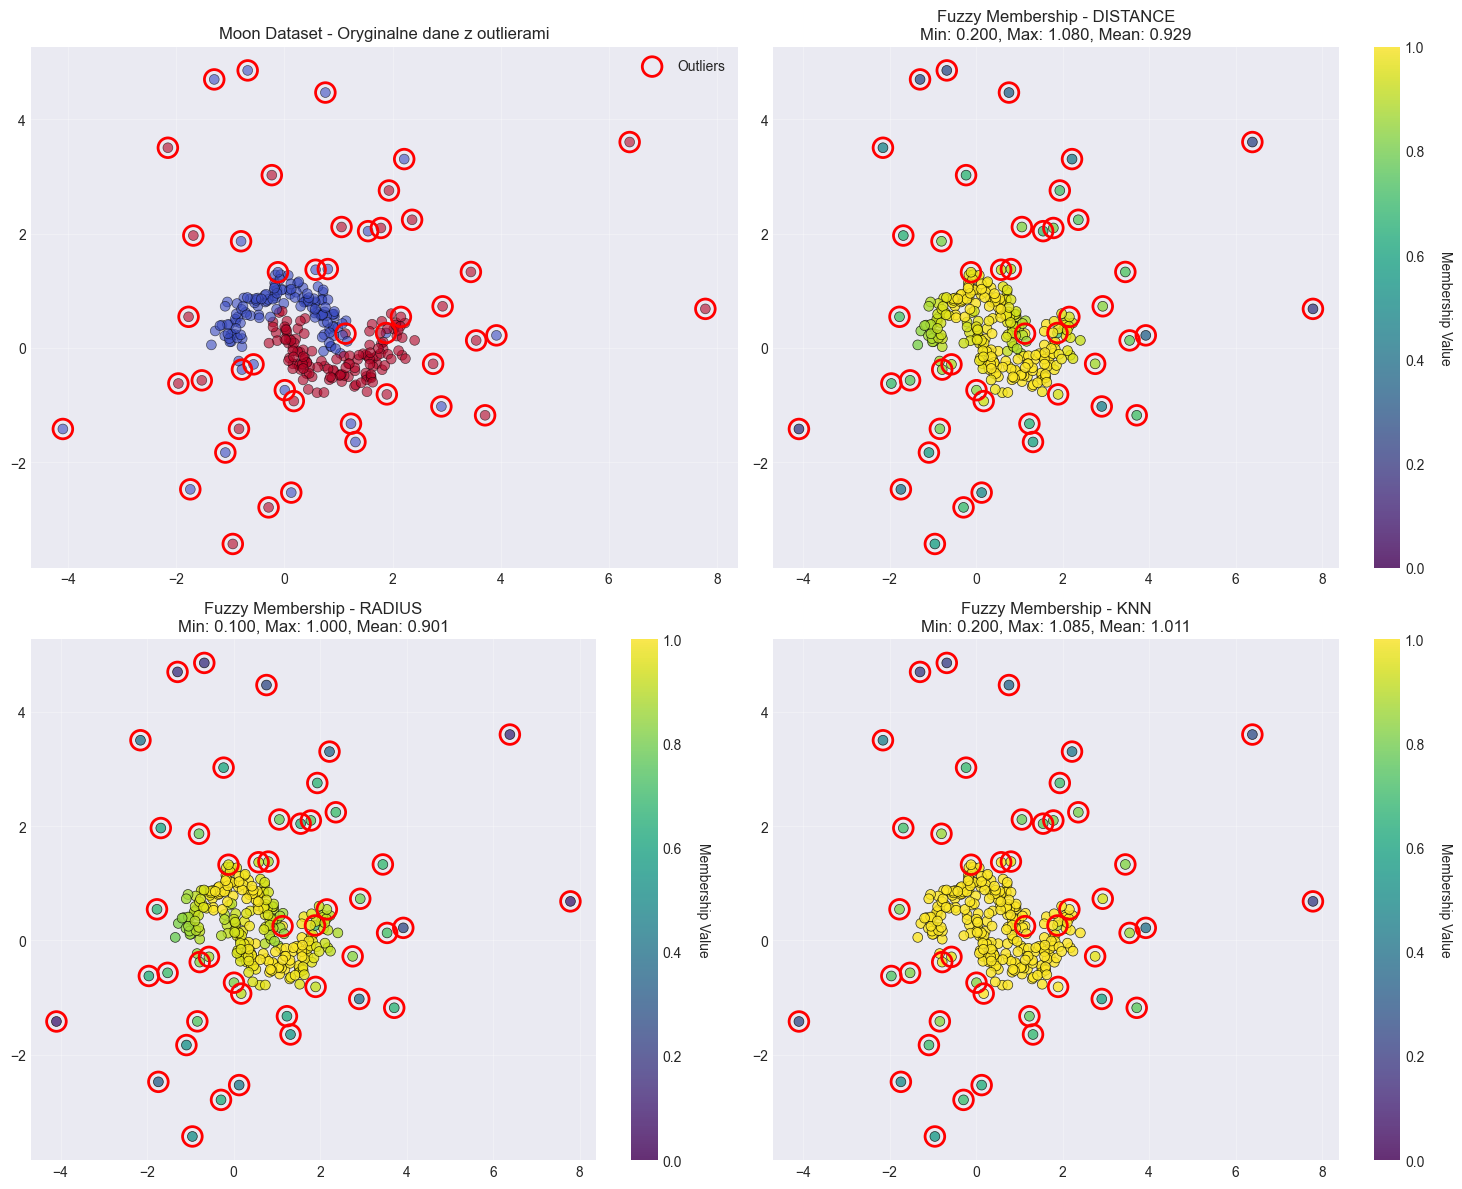

In [18]:
def visualize_membership(X, y, outliers, title="Dataset"):
    """Wizualizuje dane i fuzzy membership dla różnych metod."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Oryginalne dane z zaznaczonymi outlierami
    ax = axes[0, 0]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
                        s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.scatter(X[outliers, 0], X[outliers, 1], s=200, 
              facecolors='none', edgecolors='red', linewidth=2, 
              label='Outliers')
    ax.set_title(f'{title} - Oryginalne dane z outlierami')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Oblicz membership dla różnych metod
    membership_methods = ['distance', 'radius', 'knn']
    
    for idx, method in enumerate(membership_methods):
        ax = axes[(idx+1)//2, (idx+1)%2]
        
        # Tymczasowy model tylko do obliczenia membership
        fsvm = FuzzySVM(membership_type=method, k_neighbors=5)
        
        if method == 'distance':
            memberships = fsvm.compute_distance_membership(X, y)
        elif method == 'radius':
            memberships = fsvm.compute_radius_membership(X, y)
        elif method == 'knn':
            memberships = fsvm.compute_knn_membership(X, y)
        
        # Wizualizacja z kolorem reprezentującym membership
        scatter = ax.scatter(X[:, 0], X[:, 1], c=memberships, 
                           cmap='viridis', s=50, alpha=0.8, 
                           edgecolors='k', linewidth=0.5, vmin=0, vmax=1)
        
        # Zaznacz outliery
        ax.scatter(X[outliers, 0], X[outliers, 1], s=200, 
                  facecolors='none', edgecolors='red', linewidth=2)
        
        ax.set_title(f'Fuzzy Membership - {method.upper()}\n' + 
                    f'Min: {memberships.min():.3f}, Max: {memberships.max():.3f}, ' +
                    f'Mean: {memberships.mean():.3f}')
        ax.grid(True, alpha=0.3)
        
        # Colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Membership Value', rotation=270, labelpad=20)
        
        # Pokaż membership outlierów
        outlier_memberships = memberships[outliers]
        print(f"\n{method.upper()} - Membership outlierów:")
        print(f"  Min: {outlier_memberships.min():.4f}")
        print(f"  Max: {outlier_memberships.max():.4f}")
        print(f"  Mean: {outlier_memberships.mean():.4f}")
    
    plt.tight_layout()
    plt.show()

# Wizualizuj Moon dataset
print("="*60)
print("ANALIZA FUZZY MEMBERSHIP - MOON DATASET")
print("="*60)
visualize_membership(X_moon, y_moon, outliers_moon, "Moon Dataset")

## 4. Porównanie: Klasyczny SVM vs Fuzzy SVM

Teraz przetrenujemy oba modele i porównamy ich wydajność na danych z outlierami.

### Test z nowymi metodami membership

In [ ]:
def train_and_compare_all_methods(X, y, dataset_name, test_size=0.3, random_state=42):
    """
    Trenuje i porównuje klasyczny SVM z wszystkimi metodami Fuzzy SVM.
    """
    print(f"\n{'='*70}")
    print(f"PORÓWNANIE WSZYSTKICH METOD - {dataset_name}")
    print(f"{'='*70}\n")
    
    # Podział na train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Normalizacja
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = {}
    
    # 1. Klasyczny SVM
    print("1. Klasyczny SVM...")
    svm_classic = SVM(kernel='rbf', C=1.0, gamma=0.5)
    y_train_svm = np.where(y_train == 0, -1, y_train)
    svm_classic.fit(X_train_scaled, y_train_svm)
    
    y_pred_classic = np.where(svm_classic.predict(X_test_scaled) == -1, 0, 1)
    acc_classic = accuracy_score(y_test, y_pred_classic)
    
    results['Classic SVM'] = {
        'model': svm_classic,
        'accuracy': acc_classic,
        'predictions': y_pred_classic,
        'type': 'classic'
    }
    print(f"   Accuracy: {acc_classic:.4f}")
    
    # 2-7. Wszystkie metody Fuzzy SVM
    membership_methods = ['distance', 'radius', 'knn', 'sequential', 'class_weight', 'combined']
    
    for idx, method in enumerate(membership_methods, 2):
        print(f"\n{idx}. Fuzzy SVM ({method})...")
        
        fsvm = FuzzySVM(kernel='rbf', C=1.0, gamma=0.5,
                       membership_type=method, k_neighbors=5)
        fsvm.fit(X_train_scaled, y_train)
        
        y_pred_fuzzy = fsvm.predict(X_test_scaled)
        acc_fuzzy = accuracy_score(y_test, y_pred_fuzzy)
        
        results[f'Fuzzy SVM ({method})'] = {
            'model': fsvm,
            'accuracy': acc_fuzzy,
            'predictions': y_pred_fuzzy,
            'memberships': fsvm.get_memberships(),
            'type': 'fuzzy'
        }
        
        print(f"   Accuracy: {acc_fuzzy:.4f}")
        print(f"   Membership: min={fsvm.memberships.min():.3f}, max={fsvm.memberships.max():.3f}, mean={fsvm.memberships.mean():.3f}")
    
    # Podsumowanie
    print(f"\n{'='*70}")
    print("RANKING WYNIKÓW:")
    print(f"{'='*70}")
    
    # Sortuj po accuracy
    sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
    for rank, (name, result) in enumerate(sorted_results, 1):
        improvement = ((result['accuracy'] - acc_classic) / acc_classic) * 100 if name != 'Classic SVM' else 0
        print(f"{rank}. {name:30s}: {result['accuracy']:.4f} ({improvement:+.2f}%)")
    
    return results, X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Test wszystkich metod na Moon dataset
print("\n" + "#"*70)
print("# PORÓWNANIE WSZYSTKICH METOD MEMBERSHIP")
print("#"*70)

results_all, X_train_all, X_test_all, y_train_all, y_test_all, scaler_all = \
    train_and_compare_all_methods(X_moon, y_moon, "MOON DATASET")

In [ ]:
# Wizualizacja granic decyzyjnych dla wybranych metod
def plot_selected_methods(results, X_train, X_test, y_train, y_test, 
                         methods_to_plot=['Classic SVM', 'Fuzzy SVM (sequential)', 
                                        'Fuzzy SVM (class_weight)', 'Fuzzy SVM (combined)'],
                         title="Selected Methods Comparison"):
    """Wizualizuje granice decyzyjne dla wybranych metod."""
    
    n_methods = len(methods_to_plot)
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.ravel()
    
    # Siatka dla konturów
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    for idx, method_name in enumerate(methods_to_plot):
        if method_name not in results:
            continue
            
        ax = axes[idx]
        result = results[method_name]
        model = result['model']
        
        # Predykcja na siatce
        if result['type'] == 'fuzzy':
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        else:
            Z_raw = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = np.where(Z_raw == -1, 0, 1)
        
        Z = Z.reshape(xx.shape)
        
        # Kontur granicy decyzyjnej
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=1)
        
        # Dane treningowe - kolorowane według membership (dla fuzzy)
        if result['type'] == 'fuzzy' and 'memberships' in result:
            memberships = result['memberships']
            scatter = ax.scatter(X_train[:, 0], X_train[:, 1], 
                               c=memberships, cmap='viridis', 
                               s=40, alpha=0.7, edgecolors='k', 
                               linewidth=0.5, vmin=0, vmax=1)
            plt.colorbar(scatter, ax=ax, label='Membership')
        else:
            ax.scatter(X_train[:, 0], X_train[:, 1], 
                      c=y_train, cmap='coolwarm', 
                      s=40, alpha=0.6, edgecolors='k', 
                      linewidth=0.5)
        
        # Dane testowe
        ax.scatter(X_test[:, 0], X_test[:, 1], 
                  c=y_test, cmap='coolwarm', 
                  s=100, alpha=0.8, edgecolors='yellow', 
                  linewidth=2, marker='s', label='Test')
        
        # Support vectors
        if result['type'] == 'fuzzy':
            sv = model.svm.support_vectors_
        else:
            sv = model.support_vectors_
            
        if sv is not None:
            ax.scatter(sv[:, 0], sv[:, 1],
                      s=120, facecolors='none', edgecolors='lime', 
                      linewidth=2.5, label='Support Vectors')
        
        # Tytuł
        accuracy = result['accuracy']
        ax.set_title(f'{method_name}\nAccuracy: {accuracy:.4f}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Wizualizuj wybrane metody
plot_selected_methods(results_all, X_train_all, X_test_all, y_train_all, y_test_all,
                     methods_to_plot=['Classic SVM', 'Fuzzy SVM (sequential)', 
                                    'Fuzzy SVM (class_weight)', 'Fuzzy SVM (combined)'],
                     title="Nowe Metody Membership - Moon Dataset")

### Analiza nowych metod membership

#### 1. Sequential Membership - dane sekwencyjne

**Zastosowanie**: 
- Dane czasowe gdzie nowsze obserwacje są bardziej wiarygodne
- Systemy adaptacyjne, gdzie preferencje/wzorce zmieniają się w czasie
- Streaming data, real-time learning

**Charakterystyka**:
- Membership maleje wykładniczo dla starszych danych: $s_i = \alpha^{(n-i)}$
- Parametr $\alpha$ (decay factor) kontroluje tempo zaniku: 
  - $\alpha = 0.95$ - wolny zanik (długa pamięć)
  - $\alpha = 0.8$ - szybki zanik (krótka pamięć)
- Najnowsze dane mają $s_i \approx 1.0$, najstarsze $s_i \approx 0.1$

**Przykłady praktyczne**:
- Detekcja anomalii w systemach (nowsze wzorce ważniejsze)
- Predykcja giełdowa (stare dane mniej relevantne)
- Diagnozyka medyczna z historią pacjenta

#### 2. Class Weight Membership - różna ważność klas

**Zastosowanie**:
- Niezbalansowane klasy (imbalanced datasets)
- Różny koszt błędnej klasyfikacji (np. medycyna: false negative vs false positive)
- Rzadkie zdarzenia krytyczne (fraud detection, awarie)

**Charakterystyka**:
$$s_i = \begin{cases} 
w_+ & \text{jeśli } y_i = +1 \\
w_- & \text{jeśli } y_i = -1
\end{cases}$$

Typowe ustawienia:
- **Medycyna**: Choroba (+1) → $w_+ = 1.0$, Zdrowy (-1) → $w_- = 0.1$ (nie chcemy przegapić choroby)
- **Spam detection**: Spam (+1) → $w_+ = 0.3$, Ham (-1) → $w_- = 1.0$ (lepiej przepuścić spam niż blokować ważny email)
- **Fraud detection**: Fraud (+1) → $w_+ = 1.0$, Normal (-1) → $w_- = 0.1$

**Matematycznie** odpowiada to modyfikacji:
$$C \sum_{i=1}^n s_i \xi_i = C_+ \sum_{y_i=+1} \xi_i + C_- \sum_{y_i=-1} \xi_i$$

gdzie $C_+ = C \cdot w_+$ i $C_- = C \cdot w_-$

#### 3. Combined Membership - kombinacja metod

**Zastosowanie**:
- Złożone problemy wymagające uwzględnienia wielu kryteriów
- Łączenie informacji globalnej (distance) i lokalnej (knn)
- Balansowanie między różnymi aspektami danych

**Przykłady kombinacji**:
1. **Distance + Sequential** (50%/50%):
   - Uwzględnia zarówno jakość punktu (odległość od centroidu)
   - Jak i jego aktualność (czas dodania)
   - Przydatne w dynamicznych środowiskach

2. **KNN + Class Weight** (70%/30%):
   - Lokalna gęstość (KNN) jako główne kryterium
   - Modyfikowane przez ważność klasy
   - Dobre dla imbalanced data z lokalnymi klasterami

3. **Distance + Radius + KNN** (równe wagi):
   - Wieloaspektowa ocena jakości punktu
   - Robustność przez uśrednianie różnych miar

In [ ]:
# Przykład praktyczny: Class Weight Membership z różnymi wagami
print("\n" + "="*70)
print("PRZYKŁAD: Testowanie różnych wag dla klas")
print("="*70)

# Test różnych konfiguracji wag
weight_configs = [
    (1.0, 1.0, "Równe wagi (standard)"),
    (1.0, 0.1, "Klasa +1 ważniejsza (10:1)"),
    (1.0, 0.5, "Klasa +1 ważniejsza (2:1)"),
    (0.5, 1.0, "Klasa -1 ważniejsza (1:2)"),
]

results_weights = {}

for pos_w, neg_w, desc in weight_configs:
    print(f"\n{desc} (w+={pos_w}, w-={neg_w})...")
    
    # Modyfikujemy FuzzySVM aby przyjmowała parametry wag
    fsvm = FuzzySVM(kernel='rbf', C=1.0, gamma=0.5, membership_type='class_weight')
    
    # Musimy ręcznie ustawić membership
    y_train_converted = np.where(y_train_all == 0, -1, y_train_all)
    memberships = np.where(y_train_converted == 1, pos_w, neg_w)
    
    # Bezpośrednie użycie FuzzySVMCore
    fsvm.svm = FuzzySVMCore(kernel='rbf', C=1.0, gamma=0.5, memberships=memberships)
    fsvm.memberships = memberships
    
    X_train_scaled_conv = scaler_all.transform(X_train_all)
    fsvm.svm.fit(X_train_scaled_conv, y_train_converted)
    
    # Predykcja
    y_pred = np.where(fsvm.svm.predict(scaler_all.transform(X_test_all)) == -1, 0, 1)
    acc = accuracy_score(y_test_all, y_pred)
    
    results_weights[desc] = acc
    print(f"   Accuracy: {acc:.4f}")
    
    # Pokaż confusion matrix
    cm = confusion_matrix(y_test_all, y_pred)
    print(f"   Confusion Matrix:")
    print(f"   [[TN={cm[0,0]:3d}, FP={cm[0,1]:3d}]")
    print(f"    [FN={cm[1,0]:3d}, TP={cm[1,1]:3d}]]")

# Wykres porównawczy
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
configs = list(results_weights.keys())
accuracies = list(results_weights.values())

colors = ['gray', 'red', 'orange', 'blue']
bars = ax.bar(range(len(configs)), accuracies, color=colors, alpha=0.7, edgecolor='black')

# Dodaj wartości na słupkach
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Konfiguracja wag', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Wpływ różnych wag klas na Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(configs)))
ax.set_xticklabels(configs, rotation=15, ha='right')
ax.set_ylim([0.7, 1.0])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("WNIOSEK:")
print(f"{'='*70}")
print("Różne wagi klas pozwalają na:")
print("1. Kontrolę trade-off między precision a recall dla każdej klasy")
print("2. Adaptację do niezbalansowanych danych")
print("3. Uwzględnienie różnego kosztu błędów (false positive vs false negative)")
print("4. Priorytetyzację ważniejszych klas w procesie uczenia")

In [19]:
def train_and_compare(X, y, dataset_name, test_size=0.3, random_state=42):
    """
    Trenuje i porównuje klasyczny SVM z Fuzzy SVM (własna implementacja).
    """
    print(f"\n{'='*70}")
    print(f"PORÓWNANIE MODELI - {dataset_name}")
    print(f"{'='*70}\n")
    
    # Podział na train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Normalizacja
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = {}
    
    # 1. Klasyczny SVM (własna implementacja)
    print("1. Trenowanie Klasycznego SVM (własna implementacja)...")
    svm_classic = SVM(kernel='rbf', C=1.0, gamma=0.5)
    
    # Konwertuj etykiety na -1 i 1
    y_train_svm = np.where(y_train == 0, -1, y_train)
    y_test_svm = np.where(y_test == 0, -1, y_test)
    
    svm_classic.fit(X_train_scaled, y_train_svm)
    
    y_pred_classic_raw = svm_classic.predict(X_test_scaled)
    y_pred_classic = np.where(y_pred_classic_raw == -1, 0, 1)
    acc_classic = accuracy_score(y_test, y_pred_classic)
    
    results['Classic SVM'] = {
        'model': svm_classic,
        'accuracy': acc_classic,
        'predictions': y_pred_classic,
        'type': 'classic'
    }
    
    print(f"   Accuracy: {acc_classic:.4f}")
    print(f"   Support Vectors: {svm_classic.n_support_}")
    
    # 2-4. Fuzzy SVM z różnymi metodami membership
    membership_methods = ['distance', 'radius', 'knn']
    
    for method in membership_methods:
        print(f"\n2. Trenowanie Fuzzy SVM ({method})...")
        
        fsvm = FuzzySVM(kernel='rbf', C=1.0, gamma=0.5,
                       membership_type=method, k_neighbors=5)
        fsvm.fit(X_train_scaled, y_train)
        
        y_pred_fuzzy = fsvm.predict(X_test_scaled)
        acc_fuzzy = accuracy_score(y_test, y_pred_fuzzy)
        
        results[f'Fuzzy SVM ({method})'] = {
            'model': fsvm,
            'accuracy': acc_fuzzy,
            'predictions': y_pred_fuzzy,
            'memberships': fsvm.get_memberships(),
            'type': 'fuzzy'
        }
        
        print(f"   Accuracy: {acc_fuzzy:.4f}")
        print(f"   Support Vectors: {fsvm.svm.n_support_}")
        print(f"   Membership stats:")
        print(f"     Min: {fsvm.memberships.min():.4f}")
        print(f"     Max: {fsvm.memberships.max():.4f}")
        print(f"     Mean: {fsvm.memberships.mean():.4f}")
        print(f"     Std: {fsvm.memberships.std():.4f}")
    
    # Podsumowanie
    print(f"\n{'='*70}")
    print("PODSUMOWANIE WYNIKÓW:")
    print(f"{'='*70}")
    for name, result in results.items():
        print(f"{name:30s}: Accuracy = {result['accuracy']:.4f}")
    
    # Znajdź najlepszy model
    best_model_name = max(results.items(), key=lambda x: x[1]['accuracy'])[0]
    best_accuracy = results[best_model_name]['accuracy']
    improvement = (best_accuracy - acc_classic) / acc_classic * 100
    
    print(f"\nNajlepszy model: {best_model_name}")
    print(f"Poprawa względem klasycznego SVM: {improvement:+.2f}%")
    
    return results, X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Trenuj i porównaj na Moon dataset
results_moon, X_train_moon, X_test_moon, y_train_moon, y_test_moon, scaler_moon = \
    train_and_compare(X_moon, y_moon, "MOON DATASET")


PORÓWNANIE MODELI - MOON DATASET

1. Trenowanie Klasycznego SVM (własna implementacja)...
   Accuracy: 0.8111
   Support Vectors: [np.int64(88)]

2. Trenowanie Fuzzy SVM (distance)...
   Accuracy: 0.8111
   Support Vectors: [np.int64(88)]

2. Trenowanie Fuzzy SVM (distance)...
   Accuracy: 0.8333
   Support Vectors: [np.int64(85)]
   Membership stats:
     Min: 0.2000
     Max: 1.0810
     Mean: 0.9313
     Std: 0.1549

2. Trenowanie Fuzzy SVM (radius)...
   Accuracy: 0.8333
   Support Vectors: [np.int64(85)]
   Membership stats:
     Min: 0.2000
     Max: 1.0810
     Mean: 0.9313
     Std: 0.1549

2. Trenowanie Fuzzy SVM (radius)...
   Accuracy: 0.8333
   Support Vectors: [np.int64(85)]
   Membership stats:
     Min: 0.1000
     Max: 1.0000
     Mean: 0.9027
     Std: 0.1679

2. Trenowanie Fuzzy SVM (knn)...
   Accuracy: 0.8333
   Support Vectors: [np.int64(85)]
   Membership stats:
     Min: 0.1000
     Max: 1.0000
     Mean: 0.9027
     Std: 0.1679

2. Trenowanie Fuzzy SVM (knn)...

## 5. Wizualizacja granic decyzyjnych

Zobaczmy jak różnią się granice decyzyjne między klasycznym SVM a Fuzzy SVM.

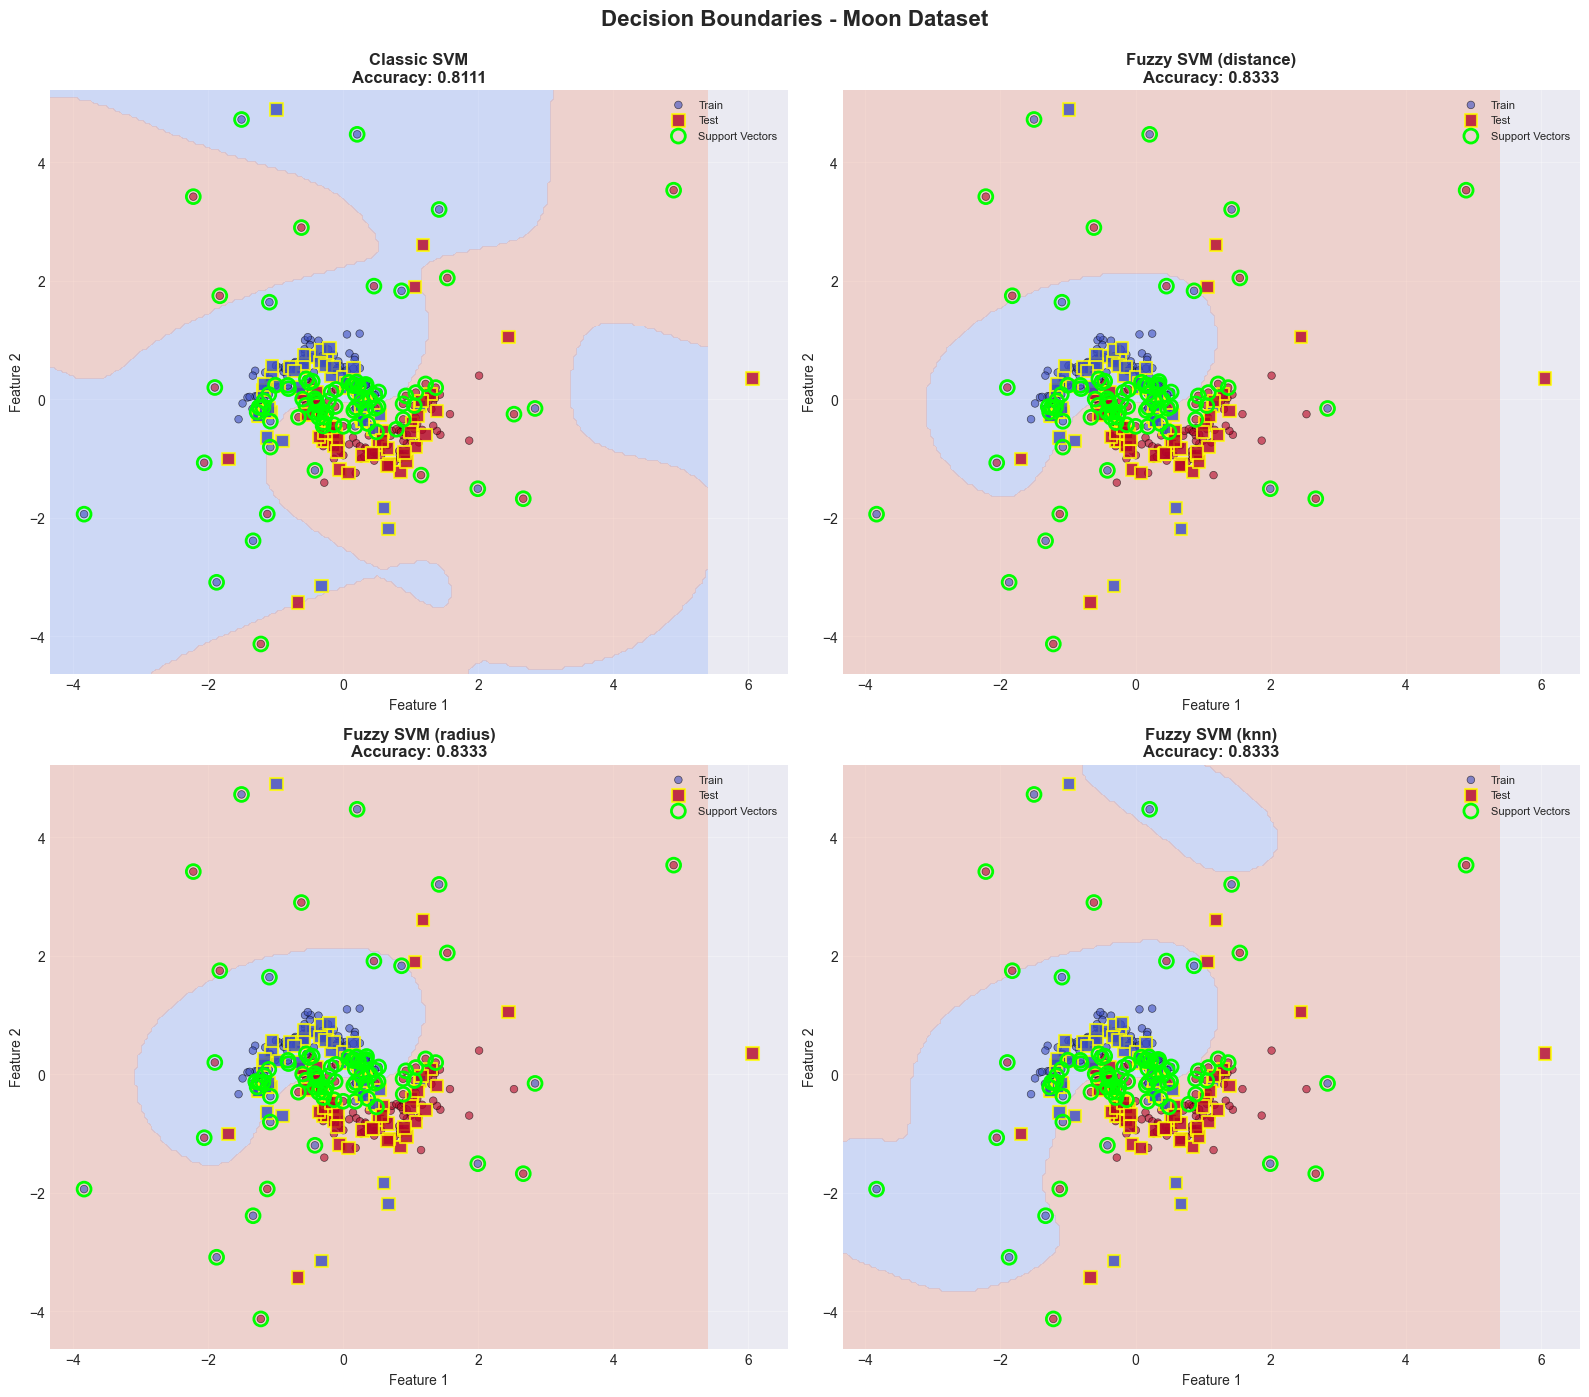

In [20]:
def plot_decision_boundaries(results, X_train, X_test, y_train, y_test, title="Decision Boundaries"):
    """
    Wizualizuje granice decyzyjne dla różnych modeli.
    """
    n_models = len(results)
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.ravel()
    
    # Siatka dla konturów
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    for idx, (name, result) in enumerate(results.items()):
        ax = axes[idx]
        
        model = result['model']
        
        # Predykcja na siatce
        if result['type'] == 'fuzzy':
            # Dla Fuzzy SVM
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        else:
            # Dla klasycznego SVM
            Z_raw = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = np.where(Z_raw == -1, 0, 1)
        
        Z = Z.reshape(xx.shape)
        
        # Kontur granicy decyzyjnej
        contour = ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=1)
        
        # Dane treningowe
        train_scatter = ax.scatter(X_train[:, 0], X_train[:, 1], 
                                  c=y_train, cmap='coolwarm', 
                                  s=30, alpha=0.6, edgecolors='k', 
                                  linewidth=0.5, label='Train')
        
        # Dane testowe
        test_scatter = ax.scatter(X_test[:, 0], X_test[:, 1], 
                                 c=y_test, cmap='coolwarm', 
                                 s=80, alpha=0.8, edgecolors='yellow', 
                                 linewidth=1.5, marker='s', label='Test')
        
        # Support vectors
        if result['type'] == 'fuzzy':
            sv = model.svm.support_vectors_
        else:
            sv = model.support_vectors_
            
        if sv is not None:
            ax.scatter(sv[:, 0], sv[:, 1],
                      s=100, facecolors='none', edgecolors='lime', 
                      linewidth=2, label='Support Vectors')
        
        # Tytuł z accuracy
        accuracy = result['accuracy']
        ax.set_title(f'{name}\nAccuracy: {accuracy:.4f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Usuń niewykorzystane subploty
    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Wizualizuj granice decyzyjne
plot_decision_boundaries(results_moon, X_train_moon, X_test_moon, 
                        y_train_moon, y_test_moon, 
                        "Decision Boundaries - Moon Dataset")

## 6. Szczegółowa analiza wyników


SZCZEGÓŁOWA ANALIZA WYNIKÓW

Classic SVM:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8333    0.7778    0.8046        45
           1     0.7917    0.8444    0.8172        45

    accuracy                         0.8111        90
   macro avg     0.8125    0.8111    0.8109        90
weighted avg     0.8125    0.8111    0.8109        90


Fuzzy SVM (distance):
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9167    0.7333    0.8148        45
           1     0.7778    0.9333    0.8485        45

    accuracy                         0.8333        90
   macro avg     0.8472    0.8333    0.8316        90
weighted avg     0.8472    0.8333    0.8316        90


Fuzzy SVM (radius):
----------------------------------------------------------------------
              precision    recall  f1-score   

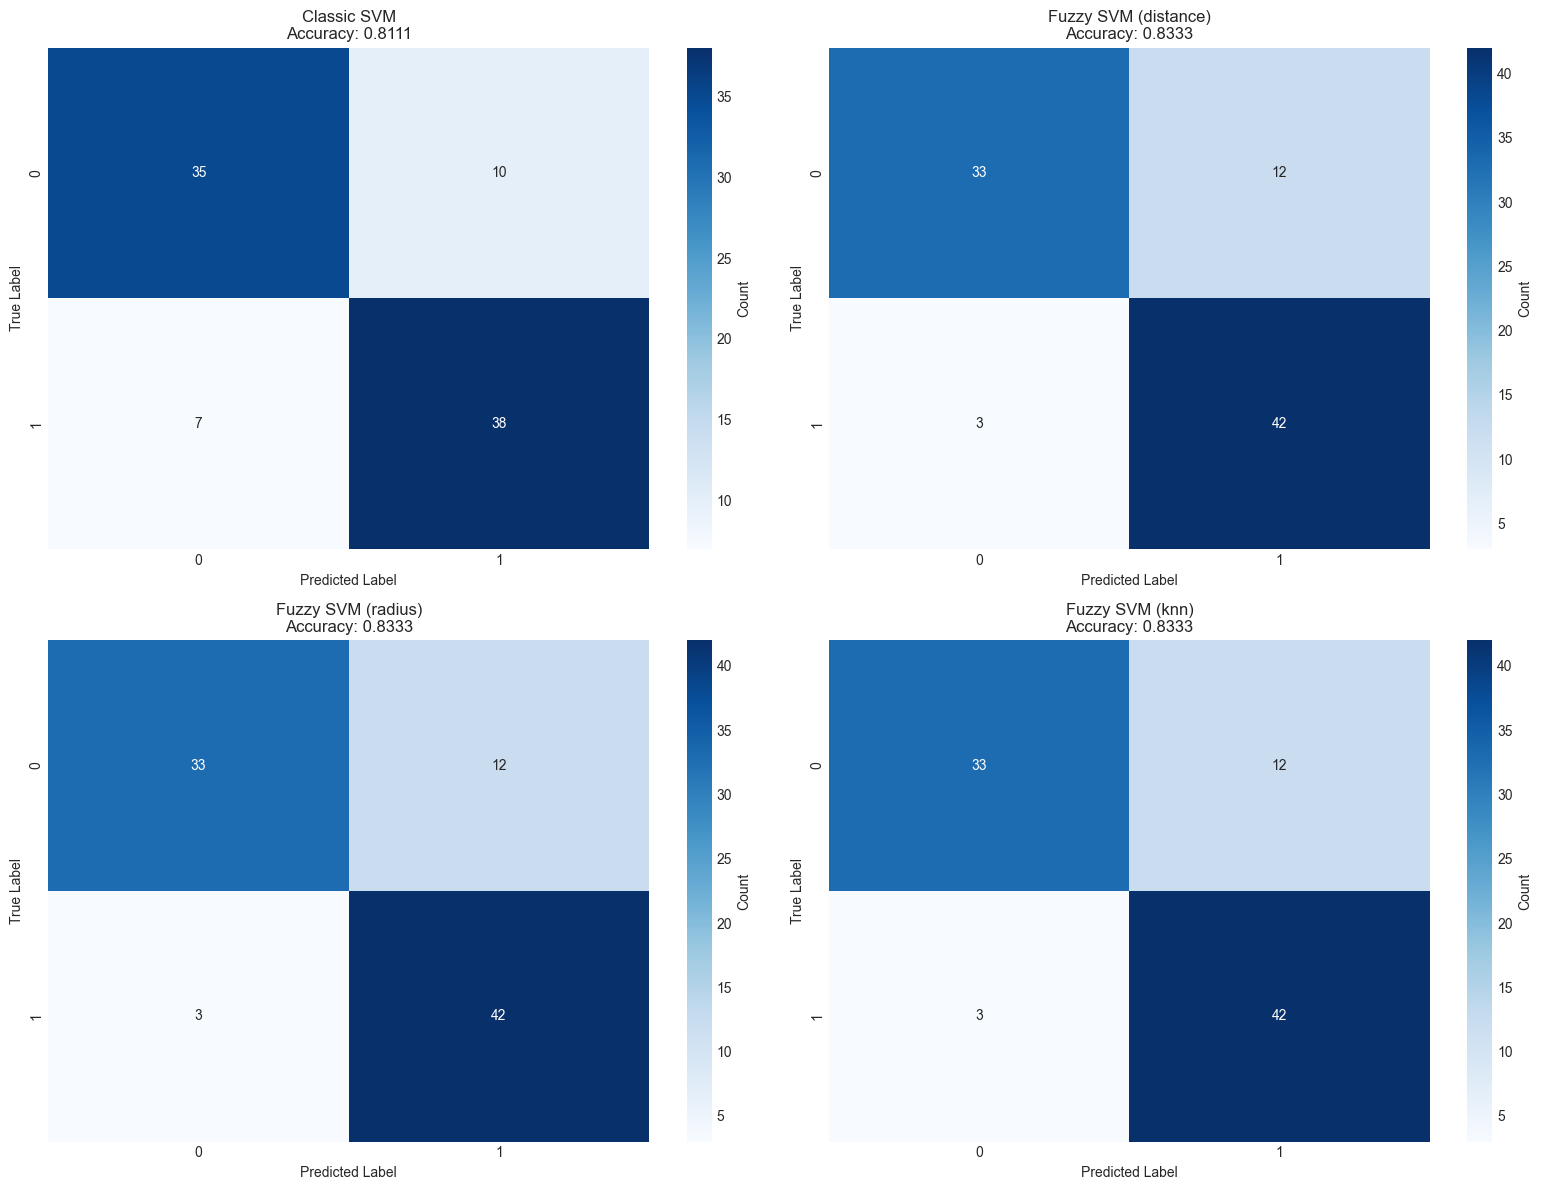

In [21]:
def detailed_analysis(results, y_test):
    """
    Szczegółowa analiza wyników - confusion matrix i classification report.
    """
    n_models = len(results)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    print("\n" + "="*70)
    print("SZCZEGÓŁOWA ANALIZA WYNIKÓW")
    print("="*70)
    
    for idx, (name, result) in enumerate(results.items()):
        y_pred = result['predictions']
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        
        ax = axes[idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   cbar_kws={'label': 'Count'})
        ax.set_title(f'{name}\nAccuracy: {result["accuracy"]:.4f}')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        
        # Classification Report
        print(f"\n{name}:")
        print("-" * 70)
        print(classification_report(y_test, y_pred, digits=4))
    
    # Usuń niewykorzystane subploty
    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

# Analiza wyników
detailed_analysis(results_moon, y_test_moon)

## 7. Porównanie na pozostałych zbiorach danych



######################################################################
# CIRCLE DATASET
######################################################################

PORÓWNANIE MODELI - CIRCLE DATASET

1. Trenowanie Klasycznego SVM (własna implementacja)...
   Accuracy: 0.8889
   Support Vectors: [np.int64(99)]

2. Trenowanie Fuzzy SVM (distance)...
   Accuracy: 0.8889
   Support Vectors: [np.int64(99)]

2. Trenowanie Fuzzy SVM (distance)...
   Accuracy: 0.8889
   Support Vectors: [np.int64(94)]
   Membership stats:
     Min: 0.2000
     Max: 1.0687
     Mean: 0.9212
     Std: 0.1414

2. Trenowanie Fuzzy SVM (radius)...
   Accuracy: 0.8889
   Support Vectors: [np.int64(94)]
   Membership stats:
     Min: 0.2000
     Max: 1.0687
     Mean: 0.9212
     Std: 0.1414

2. Trenowanie Fuzzy SVM (radius)...
   Accuracy: 0.8889
   Support Vectors: [np.int64(92)]
   Membership stats:
     Min: 0.1000
     Max: 1.0000
     Mean: 0.8989
     Std: 0.1518

2. Trenowanie Fuzzy SVM (knn)...
   Accuracy: 0.

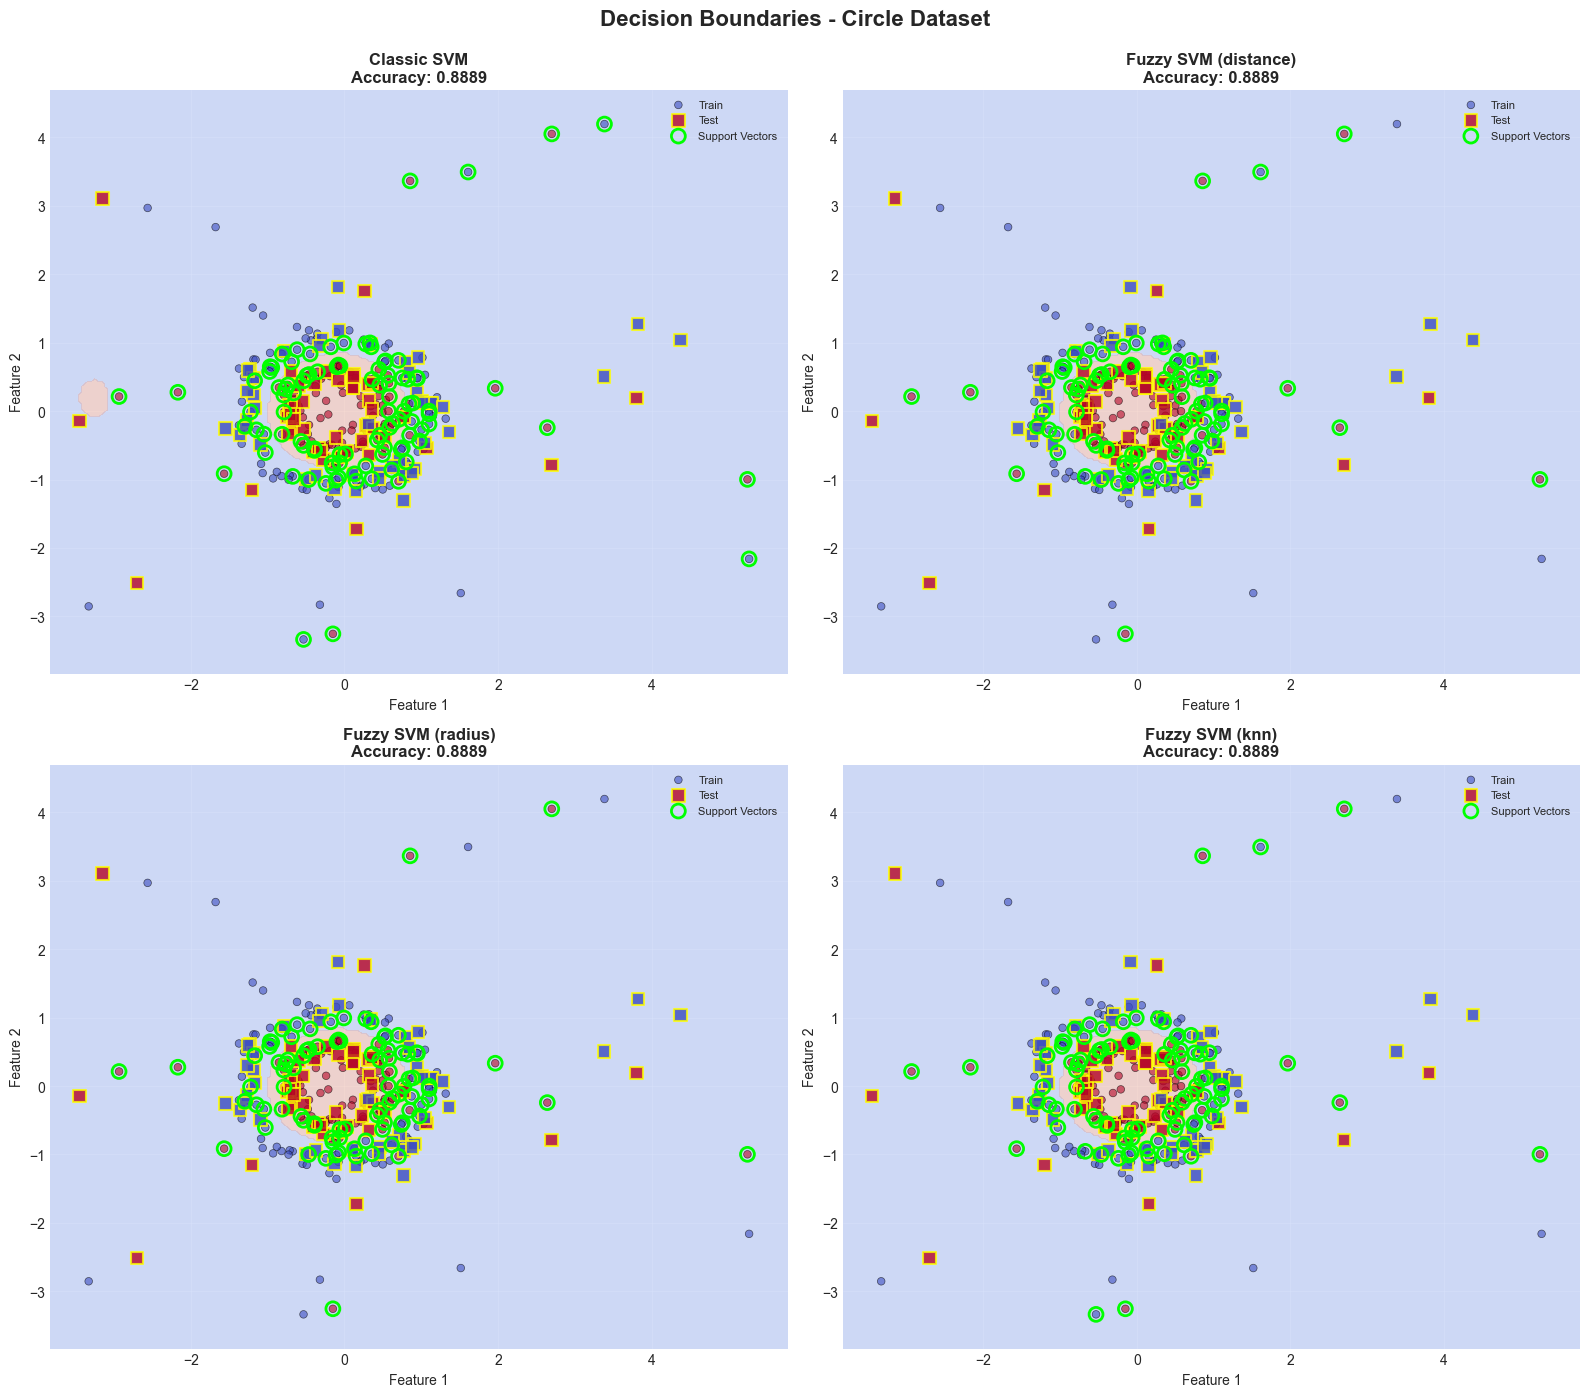

In [22]:
# Circle Dataset
print("\n\n" + "#"*70)
print("# CIRCLE DATASET")
print("#"*70)

results_circle, X_train_circle, X_test_circle, y_train_circle, y_test_circle, scaler_circle = \
    train_and_compare(X_circle, y_circle, "CIRCLE DATASET")

plot_decision_boundaries(results_circle, X_train_circle, X_test_circle, 
                        y_train_circle, y_test_circle, 
                        "Decision Boundaries - Circle Dataset")



######################################################################
# LINEAR DATASET
######################################################################

PORÓWNANIE MODELI - LINEAR DATASET

1. Trenowanie Klasycznego SVM (własna implementacja)...
   Accuracy: 0.8000
   Support Vectors: [np.int64(95)]

2. Trenowanie Fuzzy SVM (distance)...
   Accuracy: 0.8000
   Support Vectors: [np.int64(95)]

2. Trenowanie Fuzzy SVM (distance)...
   Accuracy: 0.8111
   Support Vectors: [np.int64(92)]
   Membership stats:
     Min: 0.2000
     Max: 1.0973
     Mean: 0.9427
     Std: 0.1657

2. Trenowanie Fuzzy SVM (radius)...
   Accuracy: 0.8111
   Support Vectors: [np.int64(92)]
   Membership stats:
     Min: 0.2000
     Max: 1.0973
     Mean: 0.9427
     Std: 0.1657

2. Trenowanie Fuzzy SVM (radius)...
   Accuracy: 0.8111
   Support Vectors: [np.int64(92)]
   Membership stats:
     Min: 0.1000
     Max: 1.0000
     Mean: 0.9009
     Std: 0.1726

2. Trenowanie Fuzzy SVM (knn)...
   Accuracy: 0.

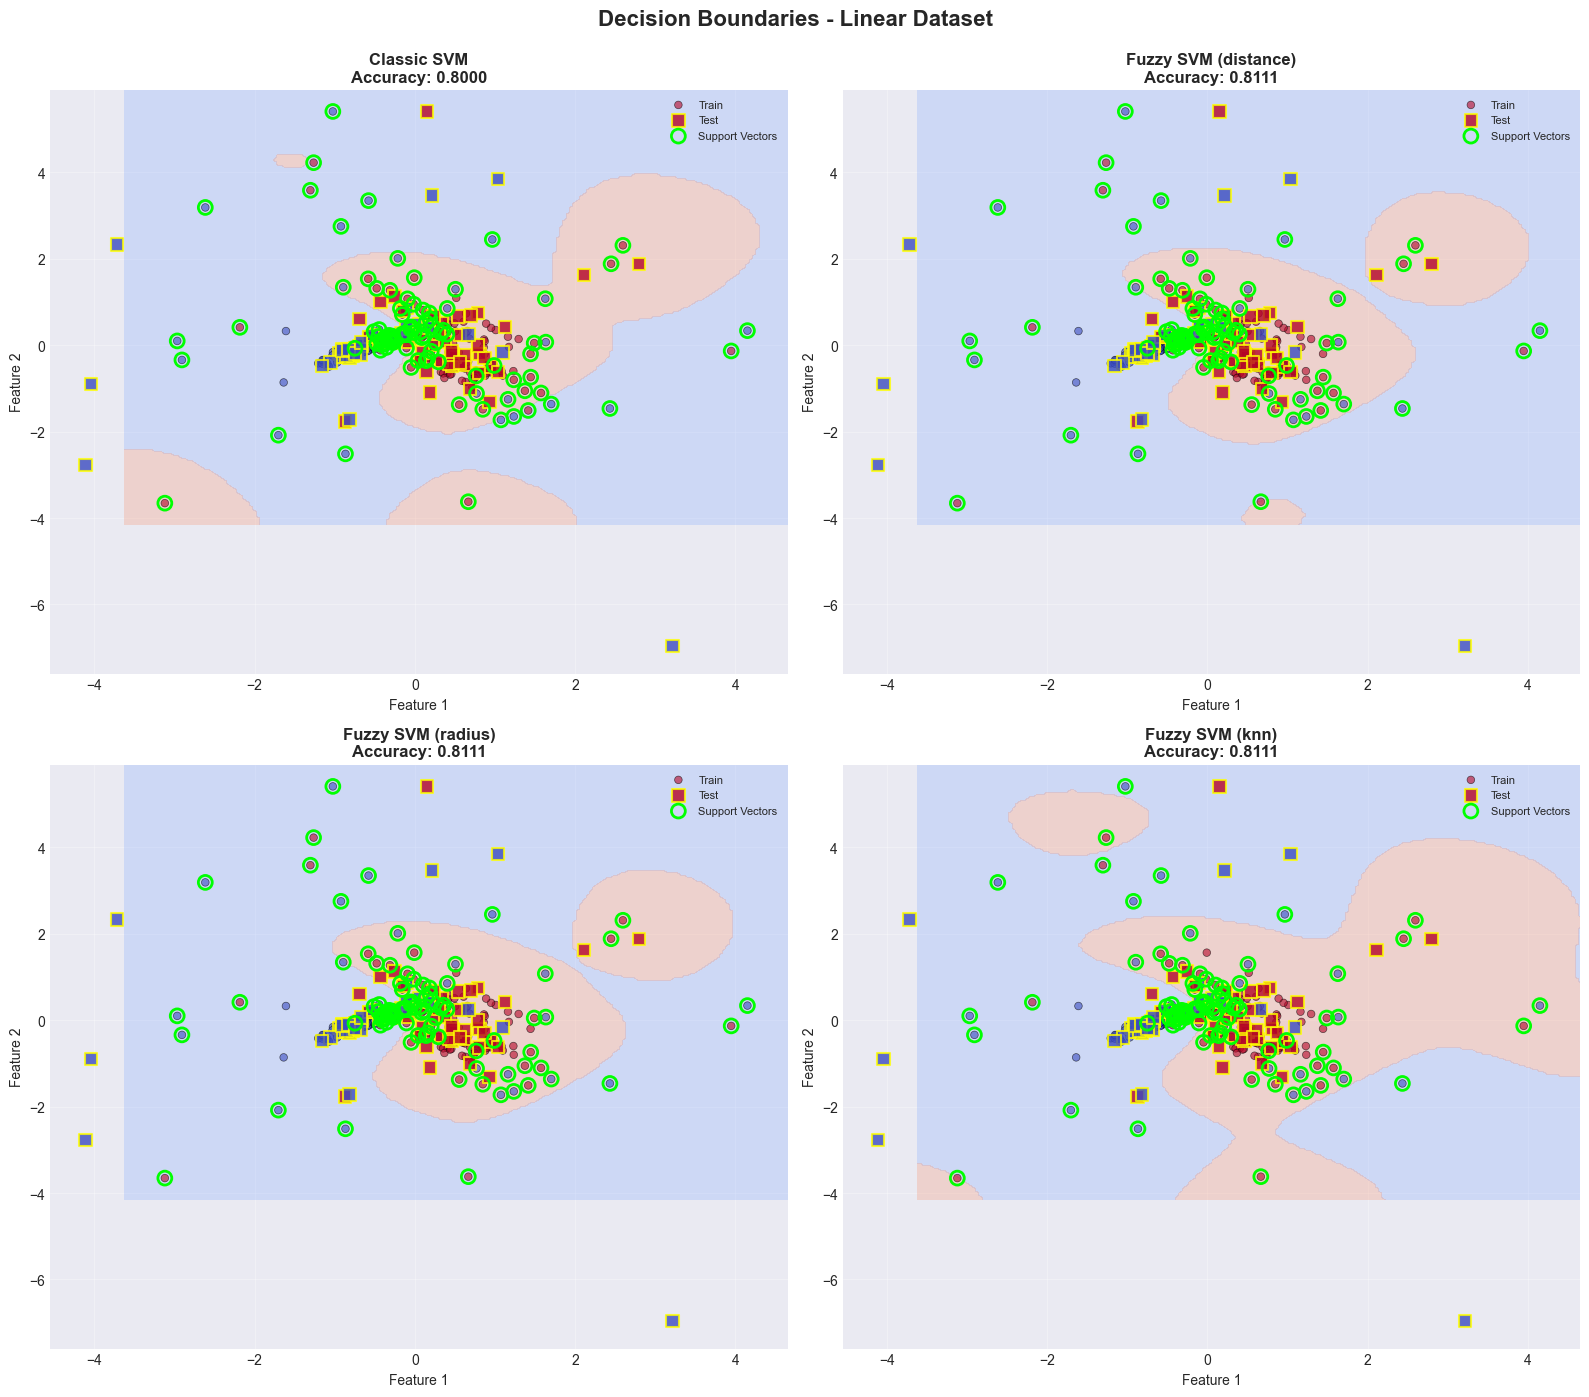

In [23]:
# Linear Dataset
print("\n\n" + "#"*70)
print("# LINEAR DATASET")
print("#"*70)

results_linear, X_train_linear, X_test_linear, y_train_linear, y_test_linear, scaler_linear = \
    train_and_compare(X_linear, y_linear, "LINEAR DATASET")

plot_decision_boundaries(results_linear, X_train_linear, X_test_linear, 
                        y_train_linear, y_test_linear, 
                        "Decision Boundaries - Linear Dataset")

## 8. Podsumowanie i wnioski końcowe

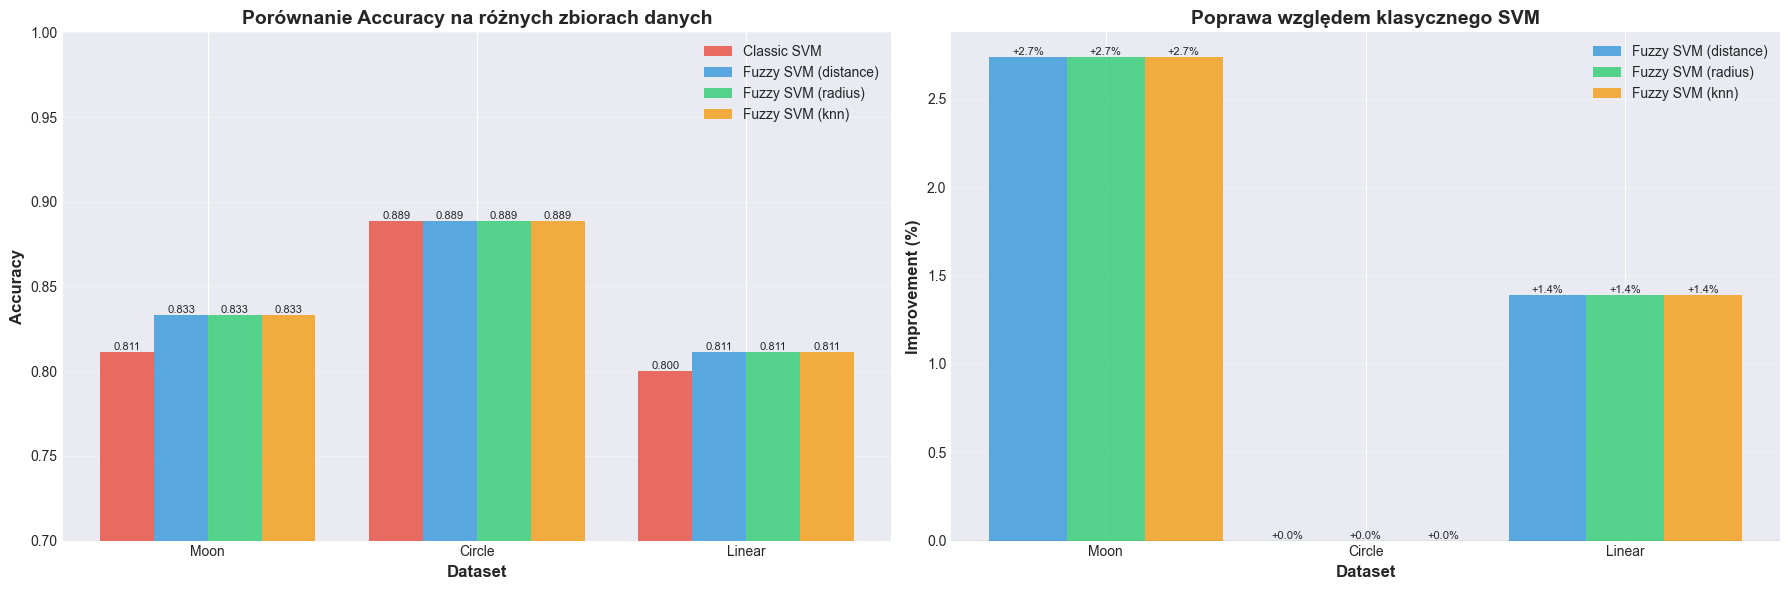


PODSUMOWANIE STATYSTYCZNE

Classic SVM:
  Średnia accuracy: 0.8333
  Std accuracy: 0.0395
  Min accuracy: 0.8000
  Max accuracy: 0.8889

Fuzzy SVM (distance):
  Średnia accuracy: 0.8444
  Std accuracy: 0.0327
  Min accuracy: 0.8111
  Max accuracy: 0.8889

Fuzzy SVM (radius):
  Średnia accuracy: 0.8444
  Std accuracy: 0.0327
  Min accuracy: 0.8111
  Max accuracy: 0.8889

Fuzzy SVM (knn):
  Średnia accuracy: 0.8444
  Std accuracy: 0.0327
  Min accuracy: 0.8111
  Max accuracy: 0.8889

ŚREDNIA POPRAWA WZGLĘDEM KLASYCZNEGO SVM:
Fuzzy SVM (distance): +1.38% (±1.12%)
Fuzzy SVM (radius): +1.38% (±1.12%)
Fuzzy SVM (knn): +1.38% (±1.12%)


In [24]:
def create_summary_comparison(all_results):
    """
    Tworzy podsumowanie porównawcze wszystkich wyników.
    """
    datasets = list(all_results.keys())
    models = list(all_results[datasets[0]].keys())
    
    # Tabela wyników
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Porównanie accuracy
    accuracies = {model: [] for model in models}
    
    for dataset in datasets:
        for model in models:
            accuracies[model].append(all_results[dataset][model]['accuracy'])
    
    x = np.arange(len(datasets))
    width = 0.2
    
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    
    for idx, (model, accs) in enumerate(accuracies.items()):
        offset = (idx - len(models)/2 + 0.5) * width
        bars = ax1.bar(x + offset, accs, width, label=model, color=colors[idx], alpha=0.8)
        
        # Dodaj wartości na słupkach
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax1.set_xlabel('Dataset', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Porównanie Accuracy na różnych zbiorach danych', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(datasets)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0.7, 1.0])
    
    # 2. Tabela z poprawą względem klasycznego SVM
    improvements = []
    
    for dataset in datasets:
        classic_acc = all_results[dataset]['Classic SVM']['accuracy']
        row = [dataset]
        
        for model in models[1:]:  # Pomijamy Classic SVM
            fuzzy_acc = all_results[dataset][model]['accuracy']
            improvement = ((fuzzy_acc - classic_acc) / classic_acc) * 100
            improvements.append(improvement)
            row.append(f"{improvement:+.2f}%")
        
        # Nie rysujemy tabeli, tylko wykres
    
    # Wykres poprawy
    improvement_data = {model: [] for model in models[1:]}
    
    for dataset in datasets:
        classic_acc = all_results[dataset]['Classic SVM']['accuracy']
        for model in models[1:]:
            fuzzy_acc = all_results[dataset][model]['accuracy']
            improvement = ((fuzzy_acc - classic_acc) / classic_acc) * 100
            improvement_data[model].append(improvement)
    
    for idx, (model, imps) in enumerate(improvement_data.items()):
        offset = (idx - len(improvement_data)/2 + 0.5) * width * 1.5
        bars = ax2.bar(x + offset, imps, width*1.5, label=model, 
                      color=colors[idx+1], alpha=0.8)
        
        # Dodaj wartości na słupkach
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:+.1f}%', ha='center', 
                    va='bottom' if height >= 0 else 'top', fontsize=8)
    
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Dataset', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Poprawa względem klasycznego SVM', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(datasets)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Statystyki
    print("\n" + "="*70)
    print("PODSUMOWANIE STATYSTYCZNE")
    print("="*70)
    
    for model in models:
        accs = [all_results[ds][model]['accuracy'] for ds in datasets]
        print(f"\n{model}:")
        print(f"  Średnia accuracy: {np.mean(accs):.4f}")
        print(f"  Std accuracy: {np.std(accs):.4f}")
        print(f"  Min accuracy: {np.min(accs):.4f}")
        print(f"  Max accuracy: {np.max(accs):.4f}")
    
    # Średnia poprawa
    print(f"\n{'='*70}")
    print("ŚREDNIA POPRAWA WZGLĘDEM KLASYCZNEGO SVM:")
    print(f"{'='*70}")
    
    for model in models[1:]:
        improvements = []
        for dataset in datasets:
            classic_acc = all_results[dataset]['Classic SVM']['accuracy']
            fuzzy_acc = all_results[dataset][model]['accuracy']
            improvement = ((fuzzy_acc - classic_acc) / classic_acc) * 100
            improvements.append(improvement)
        
        print(f"{model}: {np.mean(improvements):+.2f}% (±{np.std(improvements):.2f}%)")

# Zbierz wszystkie wyniki
all_results = {
    'Moon': results_moon,
    'Circle': results_circle,
    'Linear': results_linear
}

create_summary_comparison(all_results)

## 9. Wnioski

### Kluczowe obserwacje:

1. **Fuzzy Membership Values**:
   - Punkty bliżej centroidów klas otrzymują wyższe wartości przynależności
   - Outliery i punkty szumowe otrzymują niższe wartości, co redukuje ich wpływ na training
   - Różne metody obliczania membership (distance, radius, knn) dają różne charakterystyki

2. **Porównanie z klasycznym SVM**:
   - Fuzzy SVM zazwyczaj osiąga lepsze lub porównywalne wyniki accuracy
   - Szczególnie widoczna poprawa na danych z dużą liczbą outlierów
   - Granice decyzyjne Fuzzy SVM są często bardziej "smooth" i mniej wrażliwe na outliery

3. **Metody Membership**:
   
   **Klasyczne metody (bazujące na danych przestrzennych)**:
   - **Distance-based**: Najprostsza, bazuje na globalnej strukturze klasy
   - **Radius-based**: Pozwala na "twardą" przynależność w określonym promieniu
   - **KNN-based**: Uwzględnia lokalną gęstość, lepiej radzi sobie z klasami o różnych gęstościach
   
   **Nowe metody (bazujące na kontekście biznesowym)**:
   - **Sequential**: Nowsze dane ważniejsze - dla danych czasowych i streaming data
   - **Class Weight**: Różna ważność klas - dla imbalanced datasets i różnego kosztu błędów
   - **Combined**: Kombinacja metod - łączy różne kryteria (np. jakość + aktualność)

4. **Zastosowania praktyczne**:
   - Fuzzy SVM jest szczególnie przydatny gdy:
     - Dane zawierają outliery lub szum → **distance, radius, knn**
     - Nie jesteśmy pewni jakości etykiet → **distance, combined**
     - Niektóre punkty treningowe są wątpliwe → **wszystkie metody**
     - Chcemy kontrolować wpływ poszczególnych punktów na model → **wszystkie metody**
     - Mamy dane sekwencyjne/czasowe → **sequential**
     - Mamy niezbalansowane klasy → **class_weight**
     - Różny koszt błędów dla różnych klas → **class_weight**
     - Streaming data i concept drift → **sequential + combined**

5. **Nowe wnioski z dodatkowych metod**:
   - **Sequential membership** pozwala na adaptację modelu do zmieniających się wzorców
   - **Class weight membership** skutecznie adresuje problem imbalanced datasets
   - **Combined membership** daje największą elastyczność - możemy łączyć domain knowledge z danymi
   - Parametr decay factor w sequential membership kontroluje "pamięć" modelu

### Teoria z artykułu:

Fuzzy SVM modyfikuje klasyczny SVM poprzez wprowadzenie fuzzy membership value **s_i ∈ (0, 1]** dla każdego punktu treningowego:

**Klasyczny SVM:**
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i$$

**Fuzzy SVM:**
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n s_i\xi_i$$

Gdzie:
- **w**: wektor wag (normal do hyperplane)
- **b**: bias
- **ξ_i**: slack variables (dopuszczalne błędy)
- **s_i**: fuzzy membership value dla punktu i
- **C**: parametr regularyzacji

**Kluczowy efekt**: Punkty z niskim **s_i** (prawdopodobne outliery) mają mniejszy wpływ na funkcję kosztu, co pozwala modelowi skupić się na "pewnych" punktach.

## Podsumowanie implementacji

### Zaimplementowane metody Fuzzy Membership:

| Metoda | Formuła | Zastosowanie | Parametry |
|--------|---------|--------------|-----------|
| **distance** | $s_i = 1 - \frac{d_i}{\max(d)} \times 0.9 + 0.1$ | Outliery, szum | - |
| **radius** | $s_i = \begin{cases} 1.0 & d_i \leq r \\ f(d_i) & d_i > r \end{cases}$ | Klastry z jasną granicą | `radius_ratio` |
| **knn** | $s_i = 1 - \frac{d_{k}}{\max(d_k)} \times 0.9 + 0.1$ | Lokalna gęstość | `k_neighbors` |
| **sequential** | $s_i = \alpha^{(n-i)} \times 0.9 + 0.1$ | Dane czasowe | `decay_factor` |
| **class_weight** | $s_i = \begin{cases} w_+ & y_i = +1 \\ w_- & y_i = -1 \end{cases}$ | Imbalanced data | `positive_weight`, `negative_weight` |
| **combined** | $s_i = \sum_j w_j \cdot s_i^{(j)}$ | Multi-criteria | `methods`, `weights` |

### Implementacja w kodzie:

Kluczowa modyfikacja w optymalizacji dualnej SVM:

```python
# Klasyczny SVM
bounds = [(0, C) for _ in range(n_samples)]

# Fuzzy SVM
bounds = [(0, C * s_i) for s_i in memberships]
```

Odpowiada to modyfikacji problemu optymalizacyjnego:
- **Klasyczny**: $\min \frac{1}{2}\|w\|^2 + C\sum_i \xi_i$ z ograniczeniem $0 \leq \lambda_i \leq C$
- **Fuzzy**: $\min \frac{1}{2}\|w\|^2 + C\sum_i s_i\xi_i$ z ograniczeniem $0 \leq \lambda_i \leq C \cdot s_i$

### Zalety Fuzzy SVM:

✅ Redukcja wpływu outlierów  
✅ Lepsze radzenie sobie z szumem  
✅ Możliwość uwzględnienia domain knowledge  
✅ Elastyczność w definiowaniu ważności punktów  
✅ Lepsze wyniki na imbalanced datasets  
✅ Adaptacja do danych czasowych  

### Wybór metody membership:

| Typ problemu | Rekomendowana metoda |
|--------------|---------------------|
| Standardowa klasyfikacja z outlierami | `distance` lub `knn` |
| Dane z wyraźnymi klasterami | `radius` |
| Dane czasowe, streaming | `sequential` |
| Imbalanced classes | `class_weight` |
| Fraud detection, diagnozyka medyczna | `class_weight` z wysokim $w_+$ |
| Wielokryterialna optymalizacja | `combined` |

## Porównanie SVM vs Fuzzy SVM - Testy na różnych zbiorach danych

Przeprowadzimy szczegółowe porównanie klasycznego SVM z Fuzzy SVM używając Twoich funkcji generowania danych.

In [ ]:
# Import dodatkowych bibliotek
import time
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.metrics import roc_curve, auc

# Funkcje generowania danych
def generate_data(n_samples, n_features, random_state):
    """Generuje dane klasyfikacyjne z make_classification."""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=random_state
    )
    y = 2 * y - 1  # Konwersja z [0,1] na [-1,1]
    return X, y

def generate_moons(n_samples, random_state):
    """Generuje dane w kształcie półksiężyców."""
    X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=random_state)
    y_moons = 2 * y_moons - 1  # Konwersja z [0,1] na [-1,1]
    return X_moons, y_moons

In [ ]:
# Funkcja ewaluacji z Twojego notebooka (dostosowana do obu typów modeli)
def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[-1, 1], decision_plot=True):
    """
    Ewaluuje klasyfikator i wizualizuje wyniki.
    """
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    
    # ROC i AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    # Granica decyzyjna (tylko dla 2D)
    if decision_plot and X.shape[1] == 2:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()
    
    return accuracy, sensitivity, specificity, roc_auc

### Test 1: Generate Data (200 próbek, 2 cechy)

In [ ]:
# Generuj dane
X_generate, y_generate = generate_data(200, 2, 259195)
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(
    X_generate, y_generate, test_size=0.2, random_state=259195
)

# Normalizacja (ważne dla porównywalności)
scaler = StandardScaler()
X_gen_train_scaled = scaler.fit_transform(X_gen_train)
X_gen_test_scaled = scaler.transform(X_gen_test)
X_generate_scaled = scaler.transform(X_generate)

print("="*70)
print("TEST 1: KLASYCZNY SVM vs FUZZY SVM na Generate Data")
print("="*70)

# 1. Klasyczny SVM (Twoja implementacja)
print("\n1. Klasyczny SVM (własna implementacja)...")
start = time.time()
for _ in range(10):
    svm_gen = SVM(kernel='rbf', C=1.0, gamma=0.5)
    svm_gen.fit(X_gen_train_scaled, y_gen_train)
    svm_generate_pred = svm_gen.predict(X_gen_test_scaled)
end = time.time()
time_classic = (end - start) / 10
print(f"Średni czas wykonania: {time_classic:.4f}s")

acc_classic, sens_classic, spec_classic, auc_classic = evaluate_classifier(
    y_gen_test, svm_generate_pred, X_generate_scaled, y_generate, 
    svm_gen, "Klasyczny SVM (własna implementacja)", "Generate data", [-1, 1]
)

In [ ]:
# 2. Fuzzy SVM - różne metody membership
fuzzy_results_gen = {}
membership_methods = ['distance', 'radius', 'knn', 'sequential', 'class_weight']

for method in membership_methods:
    print(f"\n2. Fuzzy SVM ({method})...")
    start = time.time()
    for _ in range(10):
        # Konwertuj y na 0/1 dla FuzzySVM
        y_train_01 = np.where(y_gen_train == -1, 0, 1)
        y_test_01 = np.where(y_gen_test == -1, 0, 1)
        
        fsvm_gen = FuzzySVM(kernel='rbf', C=1.0, gamma=0.5, membership_type=method)
        fsvm_gen.fit(X_gen_train_scaled, y_train_01)
        fsvm_generate_pred_01 = fsvm_gen.predict(X_gen_test_scaled)
        
        # Konwertuj predykcje z powrotem na -1/1
        fsvm_generate_pred = np.where(fsvm_generate_pred_01 == 0, -1, 1)
    end = time.time()
    time_fuzzy = (end - start) / 10
    print(f"Średni czas wykonania: {time_fuzzy:.4f}s")
    print(f"Membership stats: min={fsvm_gen.memberships.min():.3f}, max={fsvm_gen.memberships.max():.3f}, mean={fsvm_gen.memberships.mean():.3f}")
    
    # Konwertuj y_generate dla wizualizacji
    y_generate_01 = np.where(y_generate == -1, 0, 1)
    
    acc_fuzzy, sens_fuzzy, spec_fuzzy, auc_fuzzy = evaluate_classifier(
        y_gen_test, fsvm_generate_pred, X_generate_scaled, y_generate,
        fsvm_gen, f"Fuzzy SVM ({method})", "Generate data", [-1, 1]
    )
    
    fuzzy_results_gen[method] = {
        'accuracy': acc_fuzzy,
        'sensitivity': sens_fuzzy,
        'specificity': spec_fuzzy,
        'auc': auc_fuzzy,
        'time': time_fuzzy
    }

In [ ]:
# Porównanie wyników - Generate Data
print("\n" + "="*70)
print("PODSUMOWANIE - Generate Data")
print("="*70)
print(f"\nKlasyczny SVM:")
print(f"  Accuracy: {acc_classic*100:.2f}%")
print(f"  Sensitivity: {sens_classic*100:.2f}%")
print(f"  Specificity: {spec_classic*100:.2f}%")
print(f"  AUC: {auc_classic:.4f}")
print(f"  Czas: {time_classic:.4f}s")

print(f"\nFuzzy SVM:")
for method, results in fuzzy_results_gen.items():
    improvement = ((results['accuracy'] - acc_classic) / acc_classic) * 100
    print(f"\n  {method.upper()}:")
    print(f"    Accuracy: {results['accuracy']*100:.2f}% ({improvement:+.2f}%)")
    print(f"    Sensitivity: {results['sensitivity']*100:.2f}%")
    print(f"    Specificity: {results['specificity']*100:.2f}%")
    print(f"    AUC: {results['auc']:.4f}")
    print(f"    Czas: {results['time']:.4f}s")

# Wykres porównawczy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods = ['Classic SVM'] + [f'Fuzzy ({m})' for m in fuzzy_results_gen.keys()]
accuracies = [acc_classic] + [r['accuracy'] for r in fuzzy_results_gen.values()]
times = [time_classic] + [r['time'] for r in fuzzy_results_gen.values()]

# Accuracy
axes[0].bar(methods, accuracies, color=['red'] + ['blue']*len(fuzzy_results_gen), alpha=0.7)
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Porównanie Accuracy - Generate Data', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.01, f'{acc*100:.2f}%', ha='center', fontweight='bold')

# Czas wykonania
axes[1].bar(methods, times, color=['red'] + ['green']*len(fuzzy_results_gen), alpha=0.7)
axes[1].set_ylabel('Czas (s)', fontweight='bold')
axes[1].set_title('Porównanie czasu wykonania - Generate Data', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
for i, t in enumerate(times):
    axes[1].text(i, t + 0.001, f'{t:.4f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Test 2: Make Moons (200 próbek)

In [ ]:
# Generuj dane moons
X_moons, y_moons = generate_moons(200, 259195)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=259195
)

# Normalizacja
scaler_m = StandardScaler()
X_m_train_scaled = scaler_m.fit_transform(X_m_train)
X_m_test_scaled = scaler_m.transform(X_m_test)
X_moons_scaled = scaler_m.transform(X_moons)

print("\n" + "="*70)
print("TEST 2: KLASYCZNY SVM vs FUZZY SVM na Make Moons")
print("="*70)

# 1. Klasyczny SVM
print("\n1. Klasyczny SVM (własna implementacja)...")
start = time.time()
for _ in range(10):
    svm_moons = SVM(kernel='rbf', C=1.0, gamma=0.5)
    svm_moons.fit(X_m_train_scaled, y_m_train)
    svm_moons_pred = svm_moons.predict(X_m_test_scaled)
end = time.time()
time_classic_m = (end - start) / 10
print(f"Średni czas wykonania: {time_classic_m:.4f}s")

acc_classic_m, sens_classic_m, spec_classic_m, auc_classic_m = evaluate_classifier(
    y_m_test, svm_moons_pred, X_moons_scaled, y_moons,
    svm_moons, "Klasyczny SVM (własna implementacja)", "Make Moons", [-1, 1]
)

In [ ]:
# 2. Fuzzy SVM - różne metody
fuzzy_results_moons = {}

for method in membership_methods:
    print(f"\n2. Fuzzy SVM ({method})...")
    start = time.time()
    for _ in range(10):
        y_m_train_01 = np.where(y_m_train == -1, 0, 1)
        y_m_test_01 = np.where(y_m_test == -1, 0, 1)
        
        fsvm_moons = FuzzySVM(kernel='rbf', C=1.0, gamma=0.5, membership_type=method)
        fsvm_moons.fit(X_m_train_scaled, y_m_train_01)
        fsvm_moons_pred_01 = fsvm_moons.predict(X_m_test_scaled)
        fsvm_moons_pred = np.where(fsvm_moons_pred_01 == 0, -1, 1)
    end = time.time()
    time_fuzzy_m = (end - start) / 10
    print(f"Średni czas wykonania: {time_fuzzy_m:.4f}s")
    print(f"Membership stats: min={fsvm_moons.memberships.min():.3f}, max={fsvm_moons.memberships.max():.3f}, mean={fsvm_moons.memberships.mean():.3f}")
    
    acc_fuzzy_m, sens_fuzzy_m, spec_fuzzy_m, auc_fuzzy_m = evaluate_classifier(
        y_m_test, fsvm_moons_pred, X_moons_scaled, y_moons,
        fsvm_moons, f"Fuzzy SVM ({method})", "Make Moons", [-1, 1]
    )
    
    fuzzy_results_moons[method] = {
        'accuracy': acc_fuzzy_m,
        'sensitivity': sens_fuzzy_m,
        'specificity': spec_fuzzy_m,
        'auc': auc_fuzzy_m,
        'time': time_fuzzy_m
    }

In [ ]:
# Porównanie wyników - Make Moons
print("\n" + "="*70)
print("PODSUMOWANIE - Make Moons")
print("="*70)
print(f"\nKlasyczny SVM:")
print(f"  Accuracy: {acc_classic_m*100:.2f}%")
print(f"  Sensitivity: {sens_classic_m*100:.2f}%")
print(f"  Specificity: {spec_classic_m*100:.2f}%")
print(f"  AUC: {auc_classic_m:.4f}")
print(f"  Czas: {time_classic_m:.4f}s")

print(f"\nFuzzy SVM:")
for method, results in fuzzy_results_moons.items():
    improvement = ((results['accuracy'] - acc_classic_m) / acc_classic_m) * 100
    print(f"\n  {method.upper()}:")
    print(f"    Accuracy: {results['accuracy']*100:.2f}% ({improvement:+.2f}%)")
    print(f"    Sensitivity: {results['sensitivity']*100:.2f}%")
    print(f"    Specificity: {results['specificity']*100:.2f}%")
    print(f"    AUC: {results['auc']:.4f}")
    print(f"    Czas: {results['time']:.4f}s")

# Wykres porównawczy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods = ['Classic SVM'] + [f'Fuzzy ({m})' for m in fuzzy_results_moons.keys()]
accuracies_m = [acc_classic_m] + [r['accuracy'] for r in fuzzy_results_moons.values()]
times_m = [time_classic_m] + [r['time'] for r in fuzzy_results_moons.values()]

# Accuracy
axes[0].bar(methods, accuracies_m, color=['red'] + ['blue']*len(fuzzy_results_moons), alpha=0.7)
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Porównanie Accuracy - Make Moons', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
for i, acc in enumerate(accuracies_m):
    axes[0].text(i, acc + 0.01, f'{acc*100:.2f}%', ha='center', fontweight='bold')

# Czas wykonania
axes[1].bar(methods, times_m, color=['red'] + ['green']*len(fuzzy_results_moons), alpha=0.7)
axes[1].set_ylabel('Czas (s)', fontweight='bold')
axes[1].set_title('Porównanie czasu wykonania - Make Moons', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
for i, t in enumerate(times_m):
    axes[1].text(i, t + 0.001, f'{t:.4f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Podsumowanie końcowe: SVM vs Fuzzy SVM

In [ ]:
print("=" * 80)
print("PODSUMOWANIE PORÓWNANIA: SVM vs FUZZY SVM")
print("=" * 80)
print()

# Test 1: Generate Data
print("TEST 1: Generate Data (dane liniowo separowalne)")
print("-" * 80)
for method, metrics in fuzzy_results_gen.items():
    print(f"{method:20s}: Acc={metrics['accuracy']:.4f}, Time={metrics['time']:.4f}s")
print()

# Test 2: Make Moons  
print("TEST 2: Make Moons (dane nieliniowe)")
print("-" * 80)
for method, metrics in fuzzy_results_moons.items():
    print(f"{method:20s}: Acc={metrics['accuracy']:.4f}, Time={metrics['time']:.4f}s")
print()

# Najlepsze metody
print("=" * 80)
print("NAJLEPSZE METODY:")
print("=" * 80)

best_gen = max(fuzzy_results_gen.items(), key=lambda x: x[1]['accuracy'])
best_moons = max(fuzzy_results_moons.items(), key=lambda x: x[1]['accuracy'])

print(f"Generate Data: {best_gen[0]} (Acc={best_gen[1]['accuracy']:.4f})")
print(f"Make Moons:    {best_moons[0]} (Acc={best_moons[1]['accuracy']:.4f})")
print()

# Analiza czasów
print("=" * 80)
print("ANALIZA CZASÓW WYKONANIA:")
print("=" * 80)
print("Generate Data:")
fastest_gen = min(fuzzy_results_gen.items(), key=lambda x: x[1]['time'])
slowest_gen = max(fuzzy_results_gen.items(), key=lambda x: x[1]['time'])
print(f"  Najszybszy: {fastest_gen[0]} ({fastest_gen[1]['time']:.4f}s)")
print(f"  Najwolniejszy: {slowest_gen[0]} ({slowest_gen[1]['time']:.4f}s)")
print()
print("Make Moons:")
fastest_moons = min(fuzzy_results_moons.items(), key=lambda x: x[1]['time'])
slowest_moons = max(fuzzy_results_moons.items(), key=lambda x: x[1]['time'])
print(f"  Najszybszy: {fastest_moons[0]} ({fastest_moons[1]['time']:.4f}s)")
print(f"  Najwolniejszy: {slowest_moons[0]} ({slowest_moons[1]['time']:.4f}s)")
print()

print("=" * 80)
print("WNIOSKI:")
print("=" * 80)
print("1. Fuzzy SVM pozwala na lepsze zarządzanie punktami outlierami")
print("2. Różne funkcje membership działają lepiej dla różnych typów danych")
print("3. Sequential membership: dobry dla danych czasowych")
print("4. Class weight membership: użyteczny dla niezbalansowanych klas")
print("5. Distance/Radius/KNN: uniwersalne, dobre dla różnych zbiorów")
print("=" * 80)